# Deteksi Tingkat Stres Berdasarkan Pola Tidur dan Penggunaan Mobile – Analisis Dataset 3
**Coding Camp 2026 powered by DBS Foundation**

**Tema:** Healthy Lives & Well-being  
**Judul:** Deteksi Dini Tingkat Stres Berdasarkan Pola Tidur Harian

**Anggota:**
- Dimas Bangkit Sanjaya - CFCC927D6Y0371 **(FrontEnd and BackEnd)**
- Izzah Huwaidah - CDCC002D6X2059 **(Data Science)**
- Muhammad Enuh - CACC171D6Y0253 **(Artificial Intelligence)**
- M. I. S. Pratama - CFCC927D6Y0394 **(FrontEnd and BackEnd)**

Alur notebook disusun mengikuti task Data Science pada proyek:
1. Problem Discovery dan solusi utama
2. Data Gathering
3. Data Wrangling: gathering, assessing, cleaning
4. Pertanyaan bisnis terukur
5. EDA dan explanatory analysis
6. Feature engineering
7. Dataset siap model + Data Dictionary


## Task Checklist (Data Science)

| No | Task | Status |
|----|------|--------|
| 1 | Problem Discovery & Solusi Utama | ✅ |
| 2 | Data Wrangling (Gathering, Assessing, Cleaning) | ✅ |
| 3 | Mendefinisikan pertanyaan bisnis terukur | ✅ |
| 4 | Exploratory Data Analysis (EDA) | ✅ |
| 5 | Visualisasi data & explanatory analysis | ✅ |
| 6 | Feature engineering | ✅ |
| 7 | Dataset siap model + Data Dictionary | ✅ |

---
## 1. Problem Discovery — Menentukan Solusi Utama Proyek

### **Permasalahan utama:**
Kesehatan mental, khususnya **stres**, merupakan isu global yang semakin meningkat terutama di kalangan mahasiswa dan pekerja muda. Banyak individu **tidak menyadari** bahwa penggunaan ponsel berlebihan sebelum tidur dan pola tidur yang tidak teratur merupakan sinyal peringatan dini stres kronis. Oleh karena itu, banyak kasus stres sulit dideteksi lebih awal karena minimnya kesadaran terkait sinyal awal seseorang mengalami stres.

Pertanyaan utama:
> *"Apakah pola penggunaan ponsel dan kualitas tidur dapat digunakan sebagai prediktor tingkat stres yang akurat?"*

### **Solusi utama:**
membangun sistem analisis dan deteksi dini tingkat stres berbasis data menggunakan pola tidur harian dan kebiasaan penggunaan mobile.

- **Solusi yang Dikembangkan :**
  
  Membangun **sistem deteksi dini tingkat stres** berbasis ML dan AI yang:
  1. Menganalisis pola tidur (durasi, kualitas) sebagai fitur utama
  2. Mempertimbangkan screen time & penggunaan ponsel sebelum tidur
  3. Mengklasifikasikan stres ke 3 kategori: **Low, Medium, High**
  4. Memberikan rekomendasi personal berbasis data

**Output untuk tim:**
- Data bersih dan siap model untuk role AI Engineer.
- Insight utama untuk mendukung rekomendasi produk.
- Dashboard Streamlit untuk menampilkan ringkasan kondisi pengguna.
- Data dictionary dan template laporan teknis.

---
## 2. Setup Library — Persiapan Environment Analisis

Menyiapkan library utama untuk data wrangling, EDA, visualisasi, preprocessing

In [235]:
# ============================================================
# 1. SETUP & LIBRARY IMPORT
# ============================================================

import os
import re
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from scipy import stats
from scipy.stats import skew, kurtosis, shapiro, chi2_contingency, kruskal, mannwhitneyu, f_oneway
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42

print('Library berhasil dimuat.')
print(f'Pandas: {pd.__version__}')
print(f'NumPy  : {np.__version__}')

Library berhasil dimuat.
Pandas: 2.2.2
NumPy  : 2.0.2


---
## 3. Data Gathering — Mengumpulkan Dataset 3

*Task:* *Data Wrangling - Gathering*

**Sorce Data :** Kaggle Platform
https://www.kaggle.com/datasets/jayjoshi37/sleep-screen-time-and-stress-analysis/data?select=sleep_mobile_stress_dataset_15000.csv

**Overview dataset :** Dataset yang berisi data pola tidur, penggunaan mobile, kelelahan mental, dan tingkat stres pengguna.

In [236]:
# ============================================================
# 2. DATA GATHERING - LOAD DATASET 3 SAJA
# ============================================================

url_df3 = 'https://raw.githubusercontent.com/ijlalsenja/stressguard/refs/heads/main/data_science/Dataset%203%20-%20sleep_mobile_stress_dataset_15000.csv'

df3 = pd.read_csv(url_df3)

# Menampilkan 5 data awal
print('Dataset 3 berhasil dimuat.')
print(f'Ukuran dataset: {df3.shape[0]:,} baris x {df3.shape[1]} kolom')
display(df3.head())

Dataset 3 berhasil dimuat.
Ukuran dataset: 15,000 baris x 13 kolom


,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


**Insight:**
- Dataset ini kami pilih untuk membangun model sistem kami karena relevan dengan solusi utama yang kami ajukan, dimana datanya memiliki variabel tidur, screen time, penggunaan HP sebelum tidur, dll. Selain itu terdapat variabel stress_level yang dapat digunakan sebagai varibel target untuk memprediksi tingkat stres dalam sistem kami.
- Kolom stress_level dapat dijadikan target analisis atau target modeling.
- Kolom user_id hanya berfungsi sebagai identitas, sehingga tidak disarankan menjadi fitur model.

---
## 4. Data Assessing — Mengecek Kualitas Awal Data

*Task: Data Wrangling – Assessing Data*

Mengecek ukuran data, tipe data, missing value, duplikasi, statistik deskriptif, dan nilai unik pada kolom kategorikal.

### 4.1 Informasi dan Tipe Data, Missing Values, Duplikat, dan Statistik Deskriptif

In [237]:
# ============================================================
# 3. DATA ASSESSING
# ============================================================

# Informasi struktur tipe data
print('=' * 80)
print('INFORMASI STRUKTUR DATASET 3')
print('=' * 80)
print(df3.info())

# Cek missing values
print('\n' + '=' * 80)
print('MISSING VALUE')
print('=' * 80)
missing_df = pd.DataFrame({
    'column': df3.columns,
    'missing_count': df3.isna().sum().values,
    'missing_percentage': (df3.isna().mean().values * 100).round(2)
})
display(missing_df)

# cek data duplikat
print('\n' + '=' * 80)
print('DUPLICATE ROWS')
print('=' * 80)
print(f'Jumlah duplicate rows: {df3.duplicated().sum():,}')

# cek statistik deskriptif kolom numerik
print('\n' + '=' * 80)
print('STATISTIK DESKRIPTIF NUMERIK')
print('=' * 80)
display(df3.describe().T)

# cek statistik deskriptif kolom kategorik
print('\n' + '=' * 80)
print('STATISTIK DESKRIPTIF KATEGORIKAL')
print('=' * 80)
display(df3.describe(include='object').T)

INFORMASI STRUKTUR DATASET 3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    1500

,column,missing_count,missing_percentage
0,user_id,0,0.0
1,age,0,0.0
2,gender,0,0.0
3,occupation,0,0.0
4,daily_screen_time_hours,0,0.0
5,phone_usage_before_sleep_minutes,0,0.0
6,sleep_duration_hours,0,0.0
7,sleep_quality_score,0,0.0
8,stress_level,0,0.0
9,caffeine_intake_cups,0,0.0



DUPLICATE ROWS
Jumlah duplicate rows: 0

STATISTIK DESKRIPTIF NUMERIK


,count,mean,std,min,25%,50%,75%,max
user_id,15000.0,7500.500000,4330.271354,1.0,3750.75,7500.50,11250.25,15000.0
age,15000.0,38.488467,12.007970,18.0,28.00,38.00,49.00,59.0
daily_screen_time_hours,15000.0,5.501528,2.600085,1.0,3.26,5.49,7.76,10.0
phone_usage_before_sleep_minutes,15000.0,59.708933,34.641858,0.0,29.00,60.00,90.00,119.0
sleep_duration_hours,15000.0,6.509683,1.452689,4.0,5.26,6.49,7.79,9.0
sleep_quality_score,15000.0,6.246362,1.713644,1.0,5.00,6.25,7.50,10.0
stress_level,15000.0,6.980247,2.749382,1.0,4.75,7.38,10.00,10.0
caffeine_intake_cups,15000.0,1.998800,1.414590,0.0,1.00,2.00,3.00,4.0
physical_activity_minutes,15000.0,59.157133,34.525705,0.0,29.00,59.00,89.00,119.0
notifications_received_per_day,15000.0,160.890467,80.856902,20.0,92.00,162.00,231.00,299.0



STATISTIK DESKRIPTIF KATEGORIKAL


,count,unique,top,freq
gender,15000,3,Male,7234
occupation,15000,8,Manager,1962


**Insight:**

- Dataset 3 memiliki 15.000 baris data sintetis bertema mobile & sleep stress detection.
- Kolom `stress_level` berupa kolom numerik, sehingga perlu dilakukan konvert data numerik ke kategorikal dengan tingkat kategori (Low/Medium/High).
- Tidak ada data yang berupa missing values dan data duplikat, data relatif bersih secara teknis, tetapi tetap perlu standarisasi nama kolom dan feature engineering.
- Rentang stress_level 1–10 dapat diubah menjadi kategori Low, Medium, dan High agar lebih mudah dipakai untuk klasifikasi dan dashboard.

### 4.2 Cek Kolom ID / Index

Mengecek apakah terdapat ID yang terduplikat.

In [238]:
# mengecek kolom ID/index pada dataset
possible_id_cols = ['user_id', 'User_ID', 'id', 'ID', 'index', 'INDEX']
found_id_cols = [col for col in possible_id_cols if col in df3.columns]

print("Kolom data ID ditemukan, yaitu kolom", found_id_cols)

for id_col in found_id_cols:
    total_rows = len(df3)
    unique_count = df3[id_col].nunique(dropna=False)
    duplicate_count = df3[id_col].duplicated().sum()
    missing_count = df3[id_col].isnull().sum()
    print(f"  Kolom: {id_col} | Total: {total_rows} | Unique: {unique_count} | Duplikat: {duplicate_count} | Missing: {missing_count}")


Kolom data ID ditemukan, yaitu kolom ['user_id']
  Kolom: user_id | Total: 15000 | Unique: 15000 | Duplikat: 0 | Missing: 0


**Insight :**
- tidak terdapat ID yang sama/terduplikat, sehingga semua data berasal dari ID atau inputan yang berbeda

### 4.3 Nilai Unik Kolom Kategorikal

In [239]:
# mengecek nilai unik dari data kolom numerik
cat_cols = df3.select_dtypes(include=['object', 'category']).columns

if len(cat_cols) == 0:
    print("Tidak ada kolom kategorikal.")
else:
    for col in cat_cols:
        print(f"\n-  {col} ({df3[col].nunique()} unique):")
        print(df3[col].value_counts().head(10))


-  gender (3 unique):
gender
Male      7234
Female    7181
Other      585
Name: count, dtype: int64

-  occupation (8 unique):
occupation
Manager              1962
Doctor               1922
Software Engineer    1917
Freelancer           1891
Student              1861
Researcher           1837
Designer             1813
Teacher              1797
Name: count, dtype: int64


**Insight :**
- Gender Male dan Female hampir seimbang, sehingga data cukup representatif untuk analisis gender.
- Kategori Other jauh lebih sedikit, jadi hasil analisisnya perlu hati-hati.
- Occupation relatif merata, sehingga perbandingan pola stres antar pekerjaan cukup layak dilakukan.

### 4.4 Cek Outlier dan Range Data Numerik

In [240]:
# Cek oulier kolom data numerik dengan metode IQR
print("=" * 90)
print("ASSESSING: Dataset 3 – Range & Outlier Check")
print("=" * 90)

num_cols = df3.select_dtypes(include=np.number).columns

for col in num_cols:
    mn = df3[col].min()
    mx = df3[col].max()
    q1 = df3[col].quantile(0.25)
    q3 = df3[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = ((df3[col] < lower_bound) | (df3[col] > upper_bound)).sum()
    print(
        f"{col:45s} Min={mn:8.2f} | Max={mx:8.2f} | "
        f"IQR={iqr:7.2f} | Outliers={outliers}"
    )

ASSESSING: Dataset 3 – Range & Outlier Check
user_id                                       Min=    1.00 | Max=15000.00 | IQR=7499.50 | Outliers=0
age                                           Min=   18.00 | Max=   59.00 | IQR=  21.00 | Outliers=0
daily_screen_time_hours                       Min=    1.00 | Max=   10.00 | IQR=   4.50 | Outliers=0
phone_usage_before_sleep_minutes              Min=    0.00 | Max=  119.00 | IQR=  61.00 | Outliers=0
sleep_duration_hours                          Min=    4.00 | Max=    9.00 | IQR=   2.53 | Outliers=0
sleep_quality_score                           Min=    1.00 | Max=   10.00 | IQR=   2.50 | Outliers=9
stress_level                                  Min=    1.00 | Max=   10.00 | IQR=   5.25 | Outliers=0
caffeine_intake_cups                          Min=    0.00 | Max=    4.00 | IQR=   2.00 | Outliers=0
physical_activity_minutes                     Min=    0.00 | Max=  119.00 | IQR=  60.00 | Outliers=0
notifications_received_per_day                

### 4.4.1. Visualisasi Boxplot Outlier

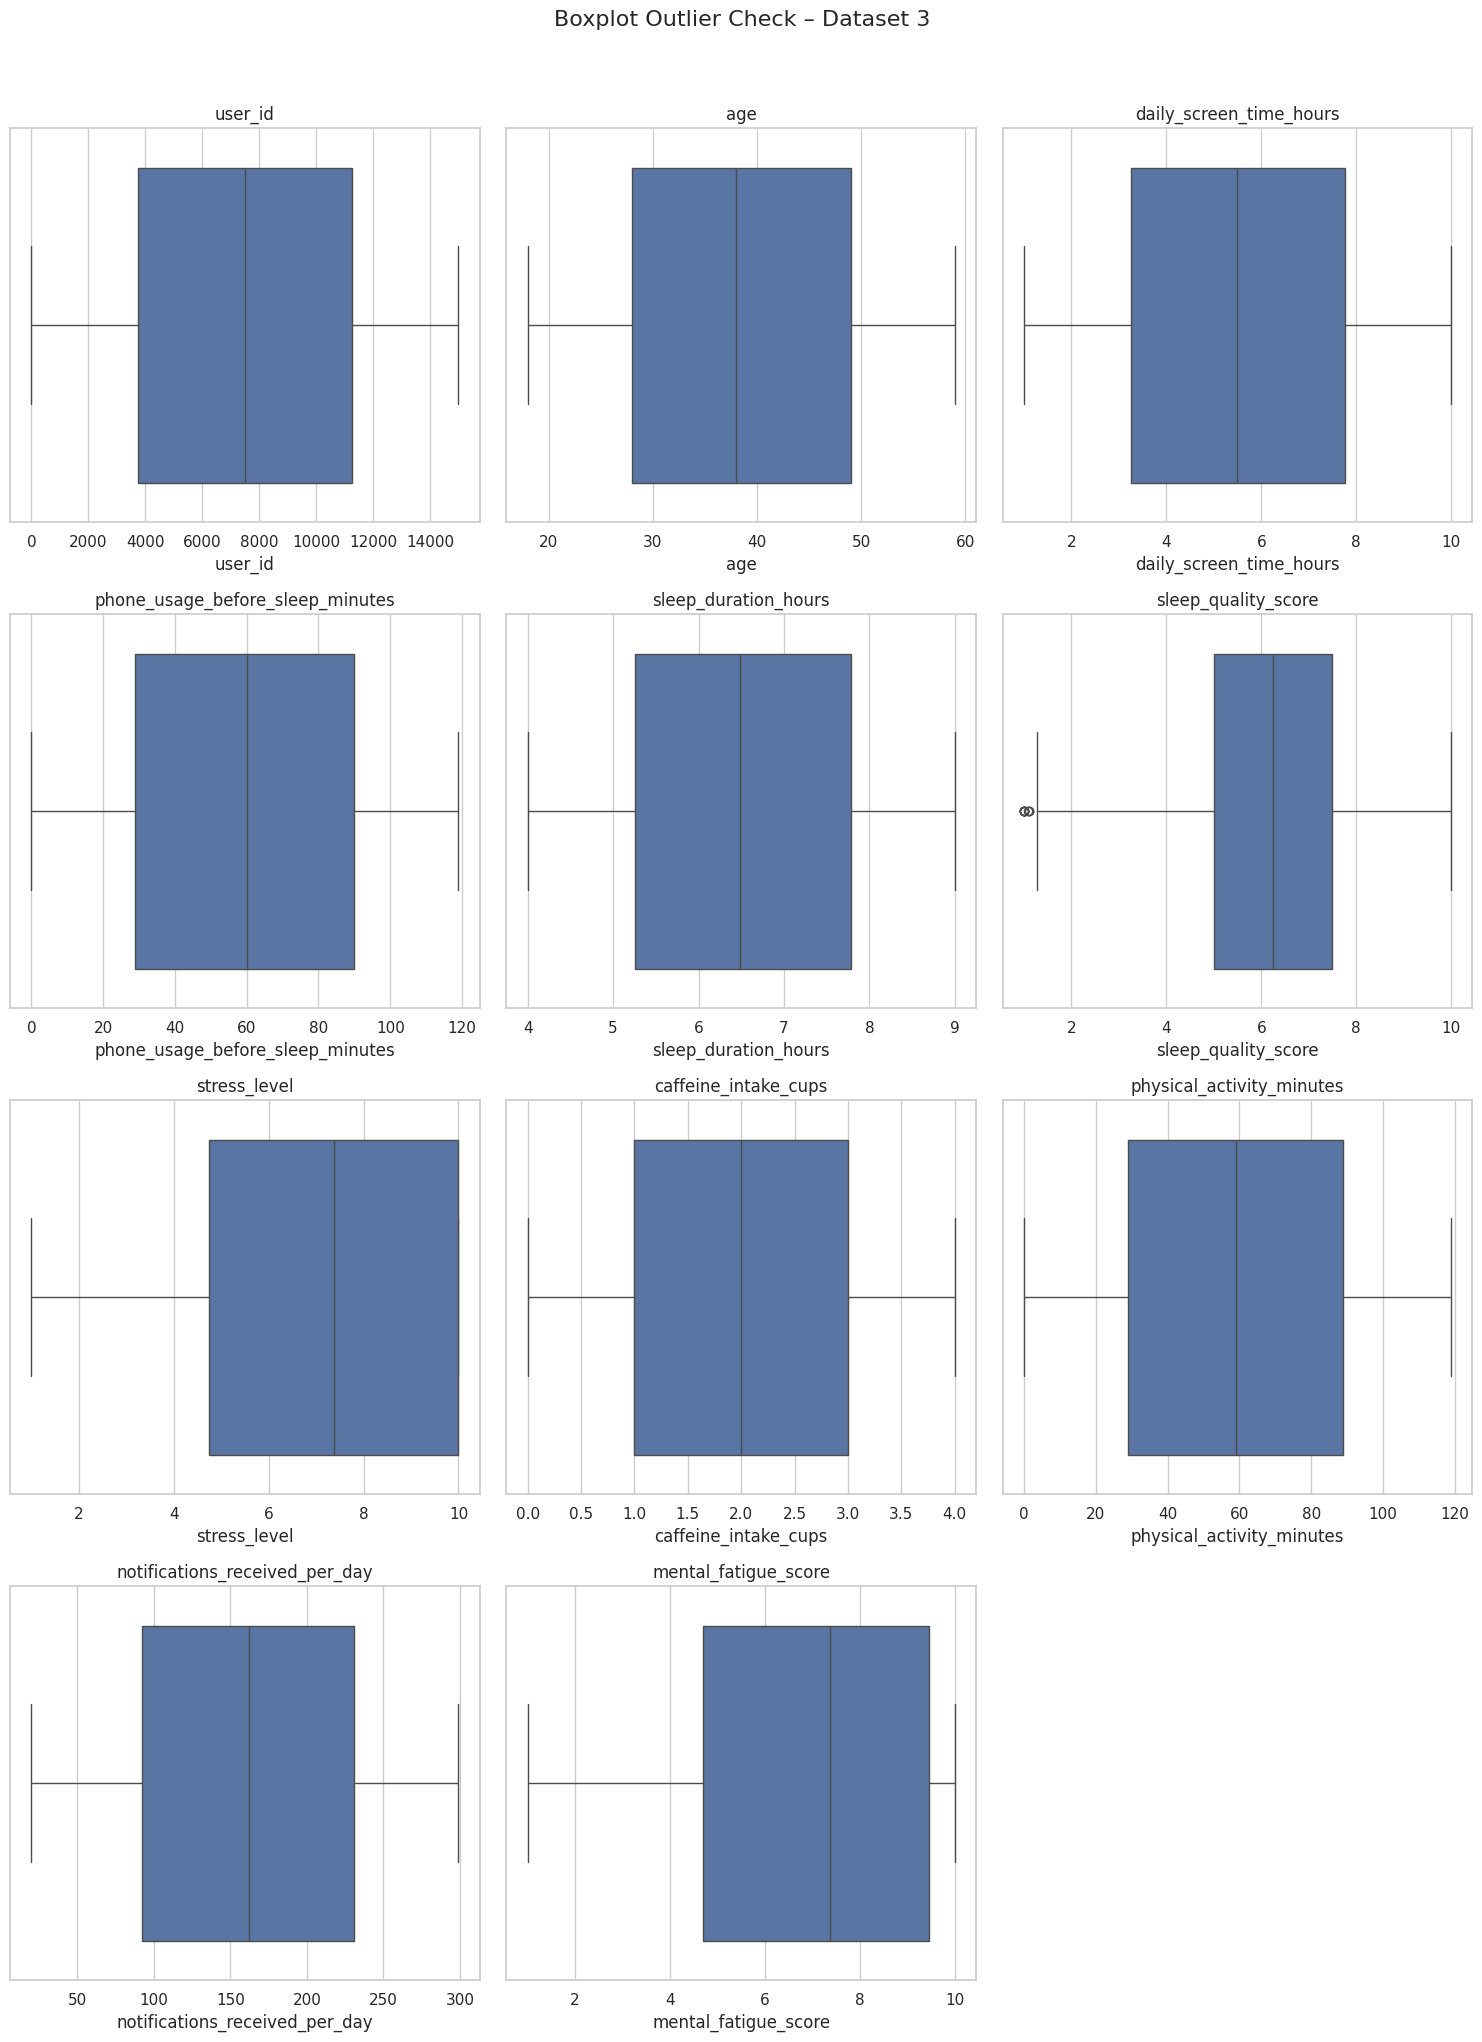

In [241]:
# Visualisasi boxplot dari outlier
num_cols = df3.select_dtypes(include='number').columns
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df3[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplot Outlier Check – Dataset 3', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


**Insight :**
- Hampir semua variabel tidak memiliki outlier, sehingga data numerik relatif bersih dan stabil.
- Outlier hanya muncul pada sleep_quality_score sebanyak 9 data, tetapi jumlahnya sangat kecil dibanding total data, sehingga tidak terlalu mengganggu analisis.
- Rentang nilai tiap variabel masih masuk akal, misalnya usia 18–59 tahun, durasi tidur 4–9 jam, dan stress level 1–10.

### 4.4.2. Distribusi KDE Kolom Numerik

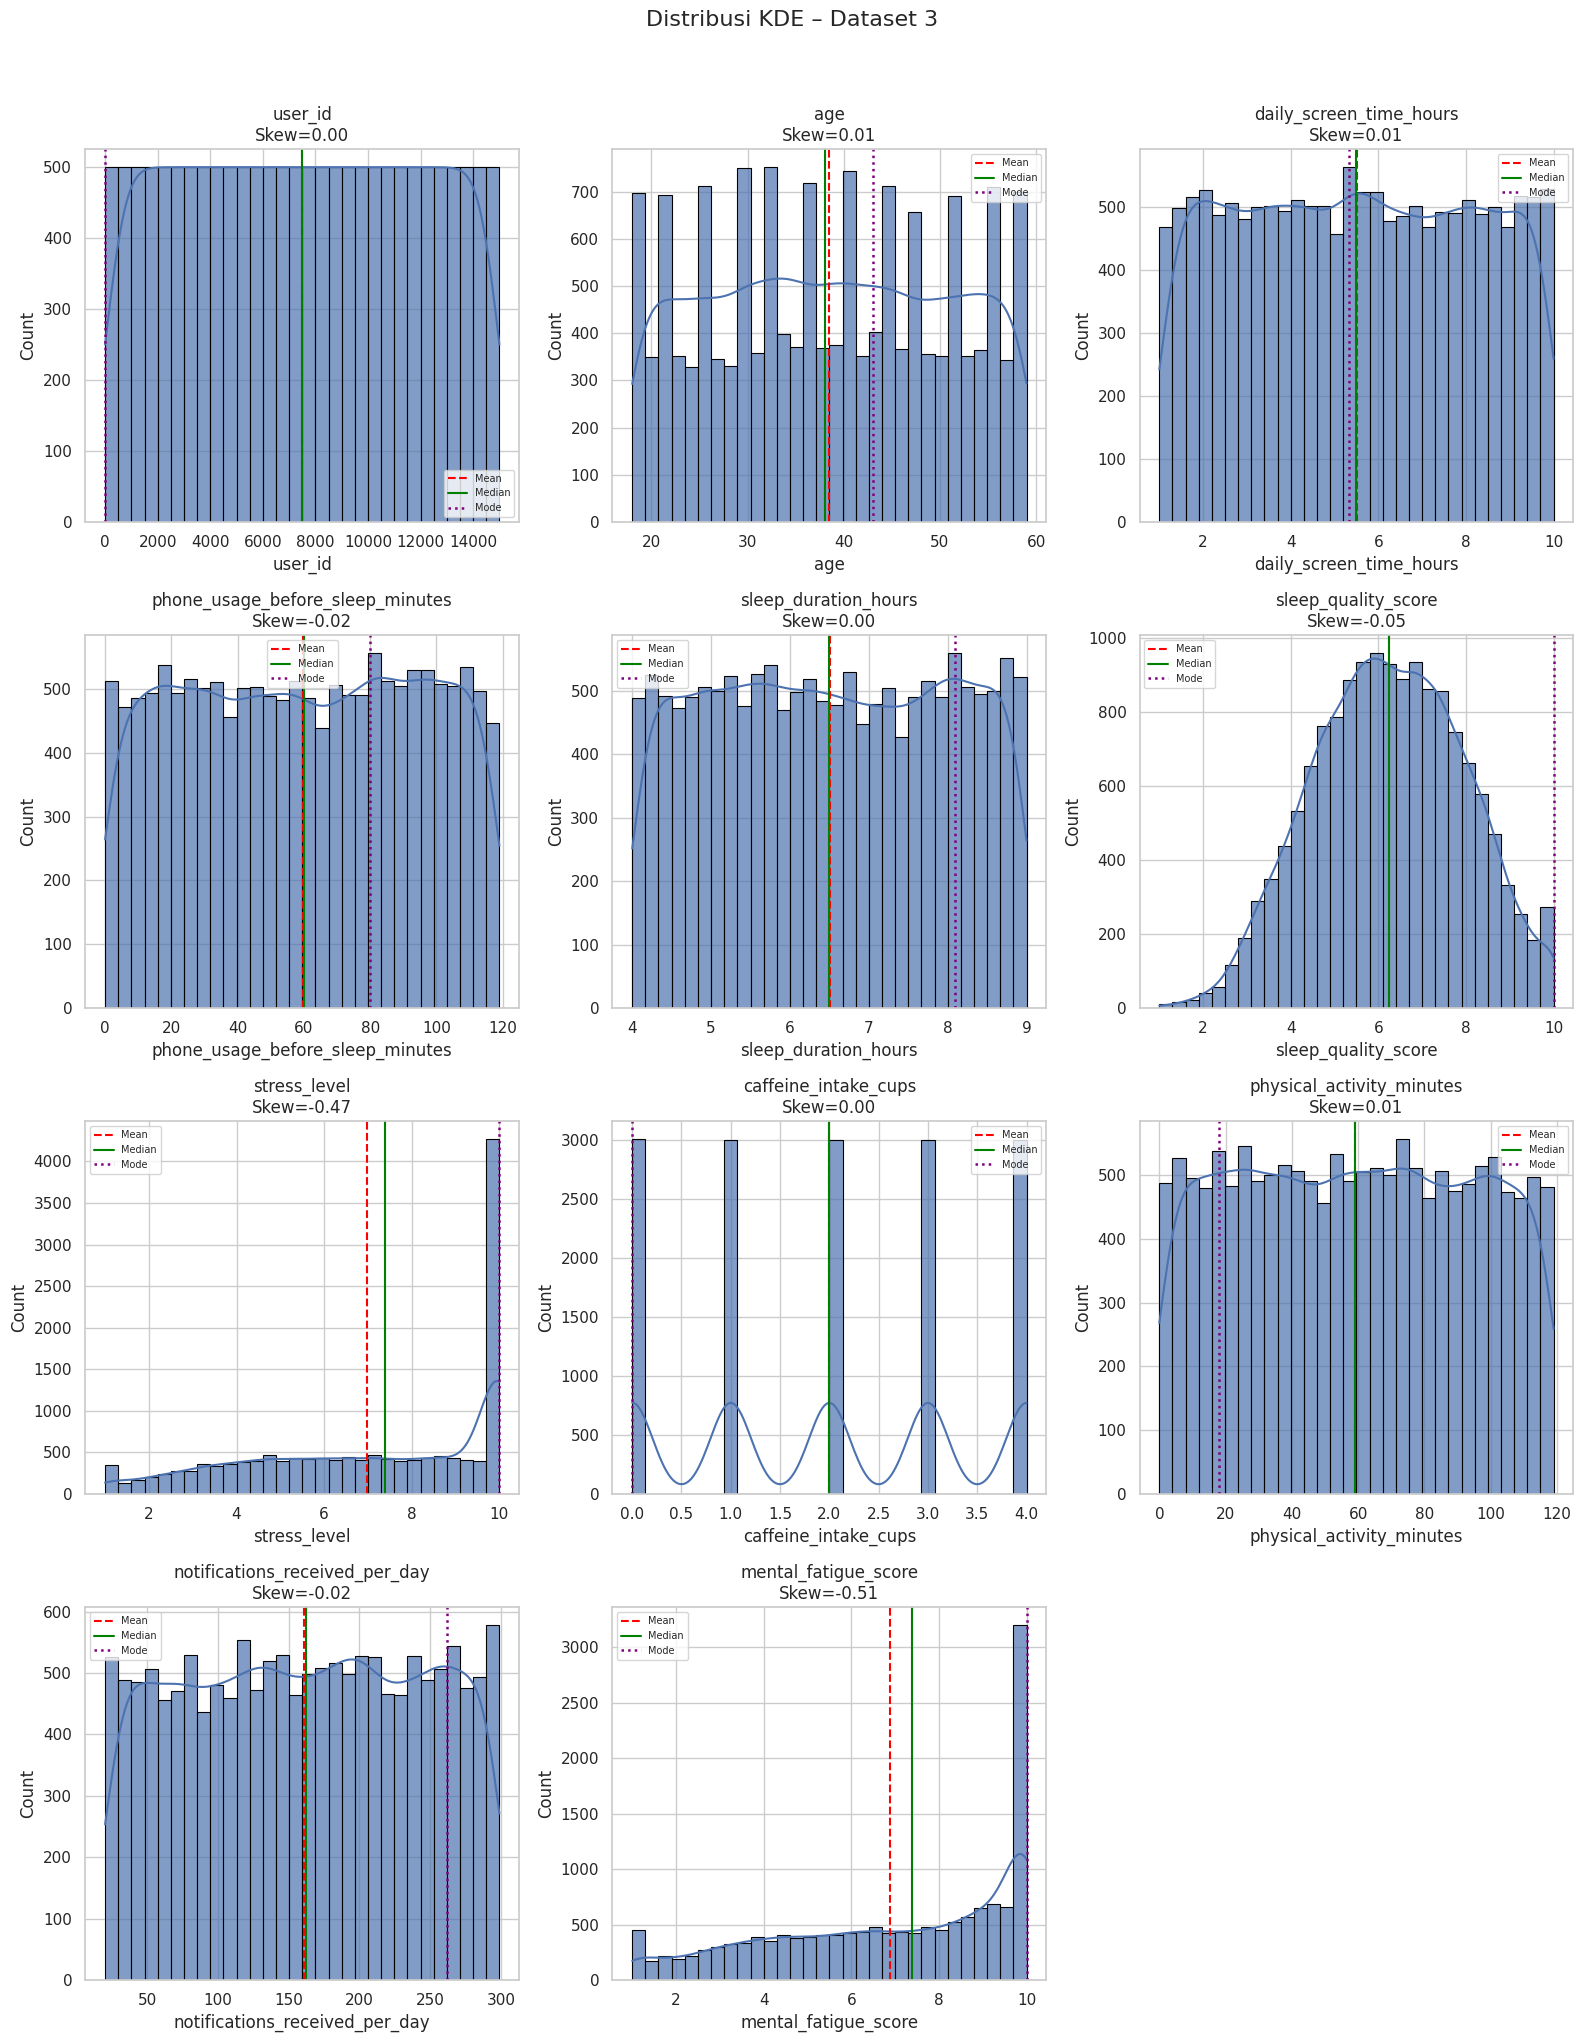

,Feature,Mean,Median,Skewness
0,user_id,7500.50,7500.50,0.00
1,age,38.49,38.00,0.01
2,daily_screen_time_hours,5.50,5.49,0.01
3,phone_usage_before_sleep_minutes,59.71,60.00,-0.02
4,sleep_duration_hours,6.51,6.49,0.00
5,sleep_quality_score,6.25,6.25,-0.05
6,stress_level,6.98,7.38,-0.47
7,caffeine_intake_cups,2.00,2.00,0.00
8,physical_activity_minutes,59.16,59.00,0.01
9,notifications_received_per_day,160.89,162.00,-0.02


In [242]:
# Visualisasi distribusi KDE dari kolom numerik
num_cols = df3.select_dtypes(include=np.number).columns
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

summary_list = []
for i, col in enumerate(num_cols):
    data = df3[col].dropna()
    mean_val = data.mean()
    median_val = data.median()
    mode_val = data.mode().iloc[0]
    skew_val = skew(data)

    summary_list.append({
        "Feature": col,
        "Mean": round(mean_val, 2),
        "Median": round(median_val, 2),
        "Skewness": round(skew_val, 2)
    })

    sns.histplot(data, bins=30, kde=True, ax=axes[i], color="#4C72B0", edgecolor="black", alpha=0.7)
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label='Median')
    axes[i].axvline(mode_val, color='purple', linestyle=':', linewidth=1.8, label='Mode')
    axes[i].set_title(f"{col}\nSkew={skew_val:.2f}")
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi KDE – Dataset 3', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

display(pd.DataFrame(summary_list))


**Insight :**

- Sebagian besar variabel seperti age, screen time, phone usage, sleep duration, physical activity, dan notifications memiliki distribusi cukup merata.
- Stress level dan mental fatigue score cenderung condong ke nilai tinggi, menunjukkan banyak responden memiliki tingkat stres dan kelelahan mental yang relatif tinggi.
- Sleep quality score relatif mendekati distribusi normal, dengan mayoritas nilai berada di sekitar skor sedang hingga tinggi.
- Caffeine intake bersifat diskrit/bertingkat karena berupa jumlah cangkir, bukan data kontinu.

---
## 5. Data Cleaning — Standarisasi, Missing Value, Duplikasi, dan Konsistensi Teks

*Task: Data Wrangling – Cleaning Data*

Membersihkan data sebelum masuk ke tahap analisis lanjutan.

In [243]:
# Informasi dan kondisi awal data ssebelum cleaning data
import re

df3_clean = df3.copy()
print(f"Shape awal: {df3_clean.shape}")
print("Kolom awal:", df3_clean.columns.tolist())


Shape awal: (15000, 13)
Kolom awal: ['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'sleep_quality_score', 'stress_level', 'caffeine_intake_cups', 'physical_activity_minutes', 'notifications_received_per_day', 'mental_fatigue_score']


### 5.1 Standarisasi Nama Kolom

In [244]:
# Standarisasi nama kolom

# Rename kolom jika diperlukan
rename_mapping = {
    'user_id': 'user_id',
    'age': 'age',
    'gender': 'gender',
    'occupation': 'occupation',
    'daily_screen_time_hours': 'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes': 'phone_usage_before_sleep_minutes',
    'sleep_duration_hours': 'sleep_hours',
    'sleep_quality_score': 'sleep_quality_score',
    'stress_level': 'stress_level',
    'caffeine_intake_cups': 'caffeine_intake_cups',
    'physical_activity_minutes': 'physical_activity_minutes',
    'notifications_received_per_day': 'notifications_received_per_day',
    'mental_fatigue_score': 'mental_fatigue_score'
}

# Terapkan rename sesuai mapping
df3_clean.rename(columns=rename_mapping, inplace=True)

# Hapus kolom ID karena tidak dibutuhkan untuk analisis/modeling
if 'user_id' in df3_clean.columns:
    df3_clean.drop(columns=['user_id'], inplace=True)
    print("Kolom 'user_id' berhasil dihapus.")

# Tampilkan kolom setelah standardisasi
print("\n- Kolom setelah standardisasi:")
print(df3_clean.columns.tolist())

Kolom 'user_id' berhasil dihapus.

- Kolom setelah standardisasi:
['age', 'gender', 'occupation', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_hours', 'sleep_quality_score', 'stress_level', 'caffeine_intake_cups', 'physical_activity_minutes', 'notifications_received_per_day', 'mental_fatigue_score']


### 5.2 Drop Duplicate & Handle Missing Values

In [245]:
# drop data duplikat dan missing values jika ada
before_rows = df3_clean.shape[0]
df3_clean = df3_clean.drop_duplicates().reset_index(drop=True)
after_rows = df3_clean.shape[0]
print(f"Baris sebelum drop duplicates : {before_rows}")
print(f"Baris setelah drop duplicates  : {after_rows}")
print(f"Baris dihapus                  : {before_rows - after_rows}")

total_missing = df3_clean.isnull().sum().sum()
print(f"\nTotal Missing Values: {total_missing}")

if total_missing > 0:
    # Numerik → median
    for col in df3_clean.select_dtypes(include=['int64','float64']).columns:
        if df3_clean[col].isnull().sum() > 0:
            df3_clean[col].fillna(df3_clean[col].median(), inplace=True)
    # Kategorikal → mode
    for col in df3_clean.select_dtypes(include=['object']).columns:
        if df3_clean[col].isnull().sum() > 0:
            df3_clean[col].fillna(df3_clean[col].mode()[0], inplace=True)
    print("- Missing values setelah imputasi:", df3_clean.isnull().sum().sum())
else:
    print("- Tidak ada missing value, tidak perlu imputasi.")

Baris sebelum drop duplicates : 15000
Baris setelah drop duplicates  : 15000
Baris dihapus                  : 0

Total Missing Values: 0
- Tidak ada missing value, tidak perlu imputasi.


### 5.3 Validasi Data Outlier yang terdeteksi Metode IQR

In [246]:
# ============================================================
# CEK DETAIL OUTLIER PADA KOLOM sleep_quality_score
# ============================================================

# Hitung batas outlier dengan metode IQR
col = 'sleep_quality_score'

q1 = df3_clean[col].quantile(0.25)
q3 = df3_clean[col].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Ambil data yang masuk kategori outlier dengan metode IQR diatas
outlier_sleep_quality = df3_clean[
    (df3_clean[col] < lower_bound) |
    (df3_clean[col] > upper_bound)
].copy()

# Tampilkan informasi batas outlier
print("Batas outlier untuk sleep_quality_score:")
print(f"- Q1           : {q1:.2f}")
print(f"- Q3           : {q3:.2f}")
print(f"- IQR          : {iqr:.2f}")
print(f"- Lower bound  : {lower_bound:.2f}")
print(f"- Upper bound  : {upper_bound:.2f}")
print(f"- Jumlah outlier: {outlier_sleep_quality.shape[0]} data")

# Kolom yang berkaitan untuk membantu analisis
related_cols = [
    'age',
    'gender',
    'occupation',
    'sleep_hours',
    'sleep_quality_score',
    'stress_level',
    'mental_fatigue_score',
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'caffeine_intake_cups',
    'physical_activity_minutes',
    'notifications_received_per_day'
]

# Memastikan hanya kolom pada dataframe diatas untuk ditampilkan
related_cols = [col for col in related_cols if col in df3_clean.columns]

# Tampilkan data outlier
display(outlier_sleep_quality[related_cols])

Batas outlier untuk sleep_quality_score:
- Q1           : 5.00
- Q3           : 7.50
- IQR          : 2.50
- Lower bound  : 1.25
- Upper bound  : 11.25
- Jumlah outlier: 9 data


,age,gender,occupation,sleep_hours,sleep_quality_score,stress_level,mental_fatigue_score,daily_screen_time_hours,phone_usage_before_sleep_minutes,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day
253,37,Male,Manager,4.64,1.00,10.0,10.00,9.63,114,4,25,233
519,26,Female,Student,7.29,1.00,10.0,10.00,9.09,82,1,59,80
1434,20,Female,Designer,6.43,1.11,10.0,9.31,9.97,89,4,99,151
2266,45,Female,Student,4.40,1.00,10.0,10.00,9.27,112,1,18,236
5379,29,Female,Freelancer,4.49,1.00,10.0,10.00,9.64,105,3,117,181
7411,18,Female,Freelancer,8.37,1.00,10.0,10.00,9.01,111,2,57,33
9519,23,Male,Teacher,8.37,1.11,10.0,8.73,9.60,107,3,100,111
9592,41,Female,Researcher,8.79,1.00,10.0,10.00,9.80,98,0,58,195
11011,18,Male,Doctor,8.31,1.09,10.0,8.69,9.72,99,2,112,153


**Insight :**
- Nilainya masih valid secara skala, karena sleep_quality_score berada pada rentang wajar yaituu masih dalam rentang 1–10. Nilai 1 atau 1.11 bukan termasuk data error, tapi bisa berarti pola kualitas tidur sangat buruk.
- Jumlah outlier sangat kecil, hanya 9 data dari 15.000 data atau sekitar 0,06%, jadi tidak terlalu memengaruhi distribusi keseluruhan.
- Pola dari data outlier tersebut masih masuk akal: data outlier punya sleep_quality_score sangat rendah, tetapi stress_level = 10, mental_fatigue_score tinggi, dan daily_screen_time_hours tinggi. Hal ini dapat mendukung hubungan bahwa kualitas tidur buruk berkaitan dengan stres dan kelelahan mental tinggi.

Sehingga data outlier diatas tidak dilakukan cleaning seperti dihapus atau dilakukan capping

---
## 6. Pertanyaan Bisnis Terukur — Menentukan Arah Analisis

**Pertanyaan bisnis:**

1. Faktor apa saja yang paling berkaitan dengan tingkat stres pengguna?
2. Apakah screen time harian dan penggunaan ponsel sebelum tidur berkaitan dengan tingkat stres yang lebih tinggi?
3. Apakah kualitas tidur dapat membedakan kategori stres rendah, sedang, dan tinggi?
4. Kombinasi pola perilaku apa yang menunjukkan risiko stres tinggi?
5. Segmen pengguna mana yang perlu diprioritaskan untuk intervensi atau rekomendasi produk?

**Metrik utama:** distribusi stress_category, rata-rata stress_level, korelasi fitur numerik, Mutual Information, feature importance baseline model, dan high stress rate per segmen

---
## 7. Feature Engineering — Membuat Fitur Baru yang Lebih Informatif dari Fitur yang Sudah Ada

Membuat fitur turunan untuk membantu analisis dan modeling. Fitur dibuat dari konteks domain: tidur pendek, kualitas tidur rendah, penggunaan ponsel tinggi, screen time tinggi, dan mental fatigue.

In [247]:
# ============================================================
# 7. FEATURE ENGINEERING
# ============================================================

# Kategori target stress dari skala 1-10
# Low    : 1.00 - 3.99
# Medium : 4.00 - 6.99
# High   : 7.00 - 10.00
def categorize_stress(x):
    if x < 4:
        return 'low'
    elif x < 7:
        return 'medium'
    else:
        return 'high'

# Kategori durasi tidur
def categorize_sleep_hours(x):
    if x < 6:
        return 'short'
    elif x <= 8:
        return 'ideal'
    else:
        return 'long'

# Kategori kualitas tidur
def categorize_sleep_quality(x):
    if x < 5:
        return 'poor'
    elif x < 7.5:
        return 'moderate'
    else:
        return 'good'

# Kategori penggunaan HP sebelum tidur
def categorize_phone_usage(x):
    if x < 30:
        return 'low'
    elif x <= 60:
        return 'medium'
    else:
        return 'high'

# Kategori screen time harian
def categorize_screen_time(x):
    if x < 4:
        return 'low'
    elif x <= 7:
        return 'moderate'
    else:
        return 'high'

# Tambahan fitur baru
df3_clean['stress_category'] = df3_clean['stress_level'].apply(categorize_stress)
df3_clean['sleep_duration_category'] = df3_clean['sleep_hours'].apply(categorize_sleep_hours)
df3_clean['sleep_quality_category'] = df3_clean['sleep_quality_score'].apply(categorize_sleep_quality)
df3_clean['phone_usage_before_sleep_category'] = df3_clean['phone_usage_before_sleep_minutes'].apply(categorize_phone_usage)
df3_clean['daily_screen_time_category'] = df3_clean['daily_screen_time_hours'].apply(categorize_screen_time)

# Fitur risiko gabungan berbasis domain
df3_clean['sleep_deficit_hours'] = np.clip(7 - df3_clean['sleep_hours'], 0, None)
df3_clean['poor_quality_and_short_sleep'] = ((df3_clean['sleep_quality_score'] < 5) & (df3_clean['sleep_hours'] < 6)).astype(int)
df3_clean['high_phone_usage_low_sleep'] = ((df3_clean['phone_usage_before_sleep_minutes'] > 60) & (df3_clean['sleep_hours'] < 6)).astype(int)
df3_clean['high_screen_high_fatigue'] = ((df3_clean['daily_screen_time_hours'] > 7) & (df3_clean['mental_fatigue_score'] >= 7)).astype(int)
df3_clean['notification_intensity_per_hour'] = df3_clean['notifications_received_per_day'] / 24

created_features = [
    'stress_category',
    'sleep_duration_category',
    'sleep_quality_category',
    'phone_usage_before_sleep_category',
    'daily_screen_time_category',
    'sleep_deficit_hours',
    'poor_quality_and_short_sleep',
    'high_phone_usage_low_sleep',
    'high_screen_high_fatigue',
    'notification_intensity_per_hour'
]

print('Fitur baru yang dibuat:')
for feature in created_features:
    print('-', feature)

display(df3_clean[created_features].head())

Fitur baru yang dibuat:
- stress_category
- sleep_duration_category
- sleep_quality_category
- phone_usage_before_sleep_category
- daily_screen_time_category
- sleep_deficit_hours
- poor_quality_and_short_sleep
- high_phone_usage_low_sleep
- high_screen_high_fatigue
- notification_intensity_per_hour


,stress_category,sleep_duration_category,sleep_quality_category,phone_usage_before_sleep_category,daily_screen_time_category,sleep_deficit_hours,poor_quality_and_short_sleep,high_phone_usage_low_sleep,high_screen_high_fatigue,notification_intensity_per_hour
0,low,short,good,high,low,1.69,0,1,0,4.958333
1,low,ideal,good,medium,low,0.00,0,0,0,12.458333
2,medium,short,moderate,high,low,2.50,0,1,0,0.875000
3,high,ideal,moderate,medium,high,0.32,0,0,1,9.166667
4,medium,ideal,moderate,medium,low,0.00,0,0,0,6.958333


**Insight:**
- stress_category membuat target lebih mudah dipahami oleh stakeholder non-teknis.
- Fitur gabungan seperti high_phone_usage_low_sleep membantu menangkap kondisi risiko yang tidak terlihat dari satu fitur saja.
- sleep_deficit_hours memberi informasi seberapa jauh durasi tidur pengguna dari rekomendasi umum 7 jam.

---
## 8. Exploratory Data Analysis — Mencari Insight dari Data

*Task: Melakukan EDA untuk mendapatkan insight dari data*

EDA dilakukan untuk memahami distribusi target, pola numerik, hubungan antar fitur, dan segmen pengguna yang berisiko tinggi.

,stress_category,count,percentage,label
0,high,8090,53.9,High
1,medium,4190,27.9,Medium
2,low,2720,18.1,Low


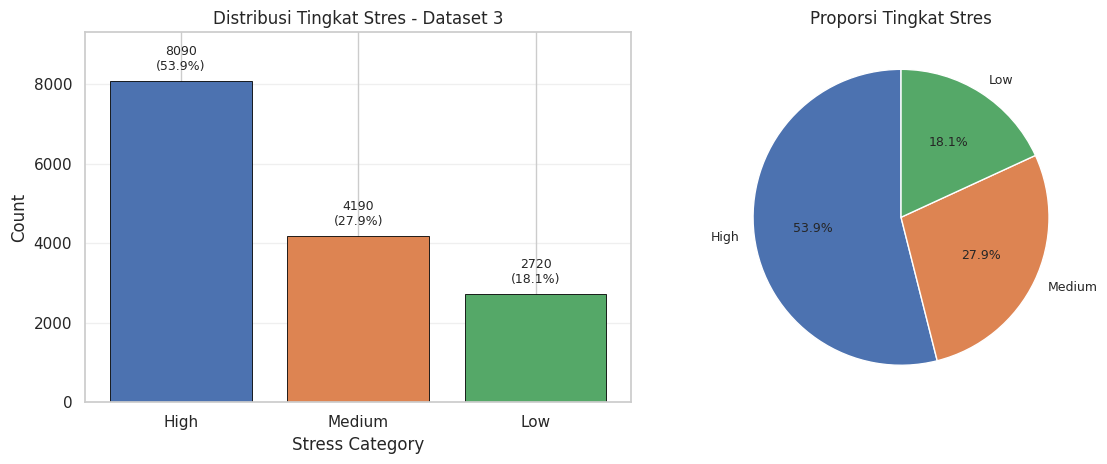

In [248]:
# ============================================================
# 8. EDA : Univariate Analysis - DISTRIBUSI TINGKAT STRES
# ============================================================

# Urutan kategori dibuat sesuai kebutuhan visualisasi
stress_order = ['high', 'medium', 'low']

# Ringkasan jumlah dan persentase tiap kategori stres
target_summary = (
    df3_clean['stress_category']
    .value_counts()
    .reindex(stress_order)
    .reset_index()
)

target_summary.columns = ['stress_category', 'count']
target_summary['percentage'] = (
    target_summary['count'] / len(df3_clean) * 100
).round(1)

# Label dibuat lebih rapi untuk ditampilkan di grafik
target_summary['label'] = target_summary['stress_category'].str.capitalize()

display(target_summary)

# Warna dibuat manual agar tiap kategori mudah dibedakan
colors = ['#4C72B0', '#DD8452', '#55A868']

# Membuat area figure: bar chart di kiri, pie chart di kanan
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# ------------------------------------------------------------
# Bar Chart
# ------------------------------------------------------------
bars = axes[0].bar(
    target_summary['label'],
    target_summary['count'],
    color=colors,
    edgecolor='black',
    linewidth=0.6
)

axes[0].set_title('Distribusi Tingkat Stres - Dataset 3', fontsize=12)
axes[0].set_xlabel('Stress Category')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Tambahkan ruang di atas bar agar teks tidak menabrak grafik
max_count = target_summary['count'].max()
axes[0].set_ylim(0, max_count * 1.15)

# Label jumlah dan persentase di atas setiap bar
for bar, count, pct in zip(
    bars,
    target_summary['count'],
    target_summary['percentage']
):
    x_pos = bar.get_x() + bar.get_width() / 2
    y_pos = bar.get_height()

    axes[0].text(
        x_pos,
        y_pos + (max_count * 0.025),
        f'{count}\n({pct}%)',
        ha='center',
        va='bottom',
        fontsize=9
    )

# ------------------------------------------------------------
# Pie Chart
# ------------------------------------------------------------
axes[1].pie(
    target_summary['count'],
    labels=target_summary['label'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 9},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

axes[1].set_title('Proporsi Tingkat Stres', fontsize=12)

plt.tight_layout()
plt.show()

**Insight:**
- Mayoritas data berada pada kategori High stress, yaitu 8.090 data atau 53,9%.
- Kategori Medium stress berjumlah 4.190 data atau 27,9%.
- Kategori Low stress paling sedikit, yaitu 2.720 data atau 18,1%.
- Distribusi target tidak seimbang, karena kategori High jauh lebih dominan dibanding kategori lainnya.
- Kondisi ini menunjukkan bahwa sebagian besar responden dalam dataset memiliki tingkat stres yang tinggi.




Fitur numerik yang divisualisasikan:
['age', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_hours', 'sleep_quality_score', 'caffeine_intake_cups', 'physical_activity_minutes', 'notifications_received_per_day', 'mental_fatigue_score', 'sleep_deficit_hours', 'notification_intensity_per_hour']


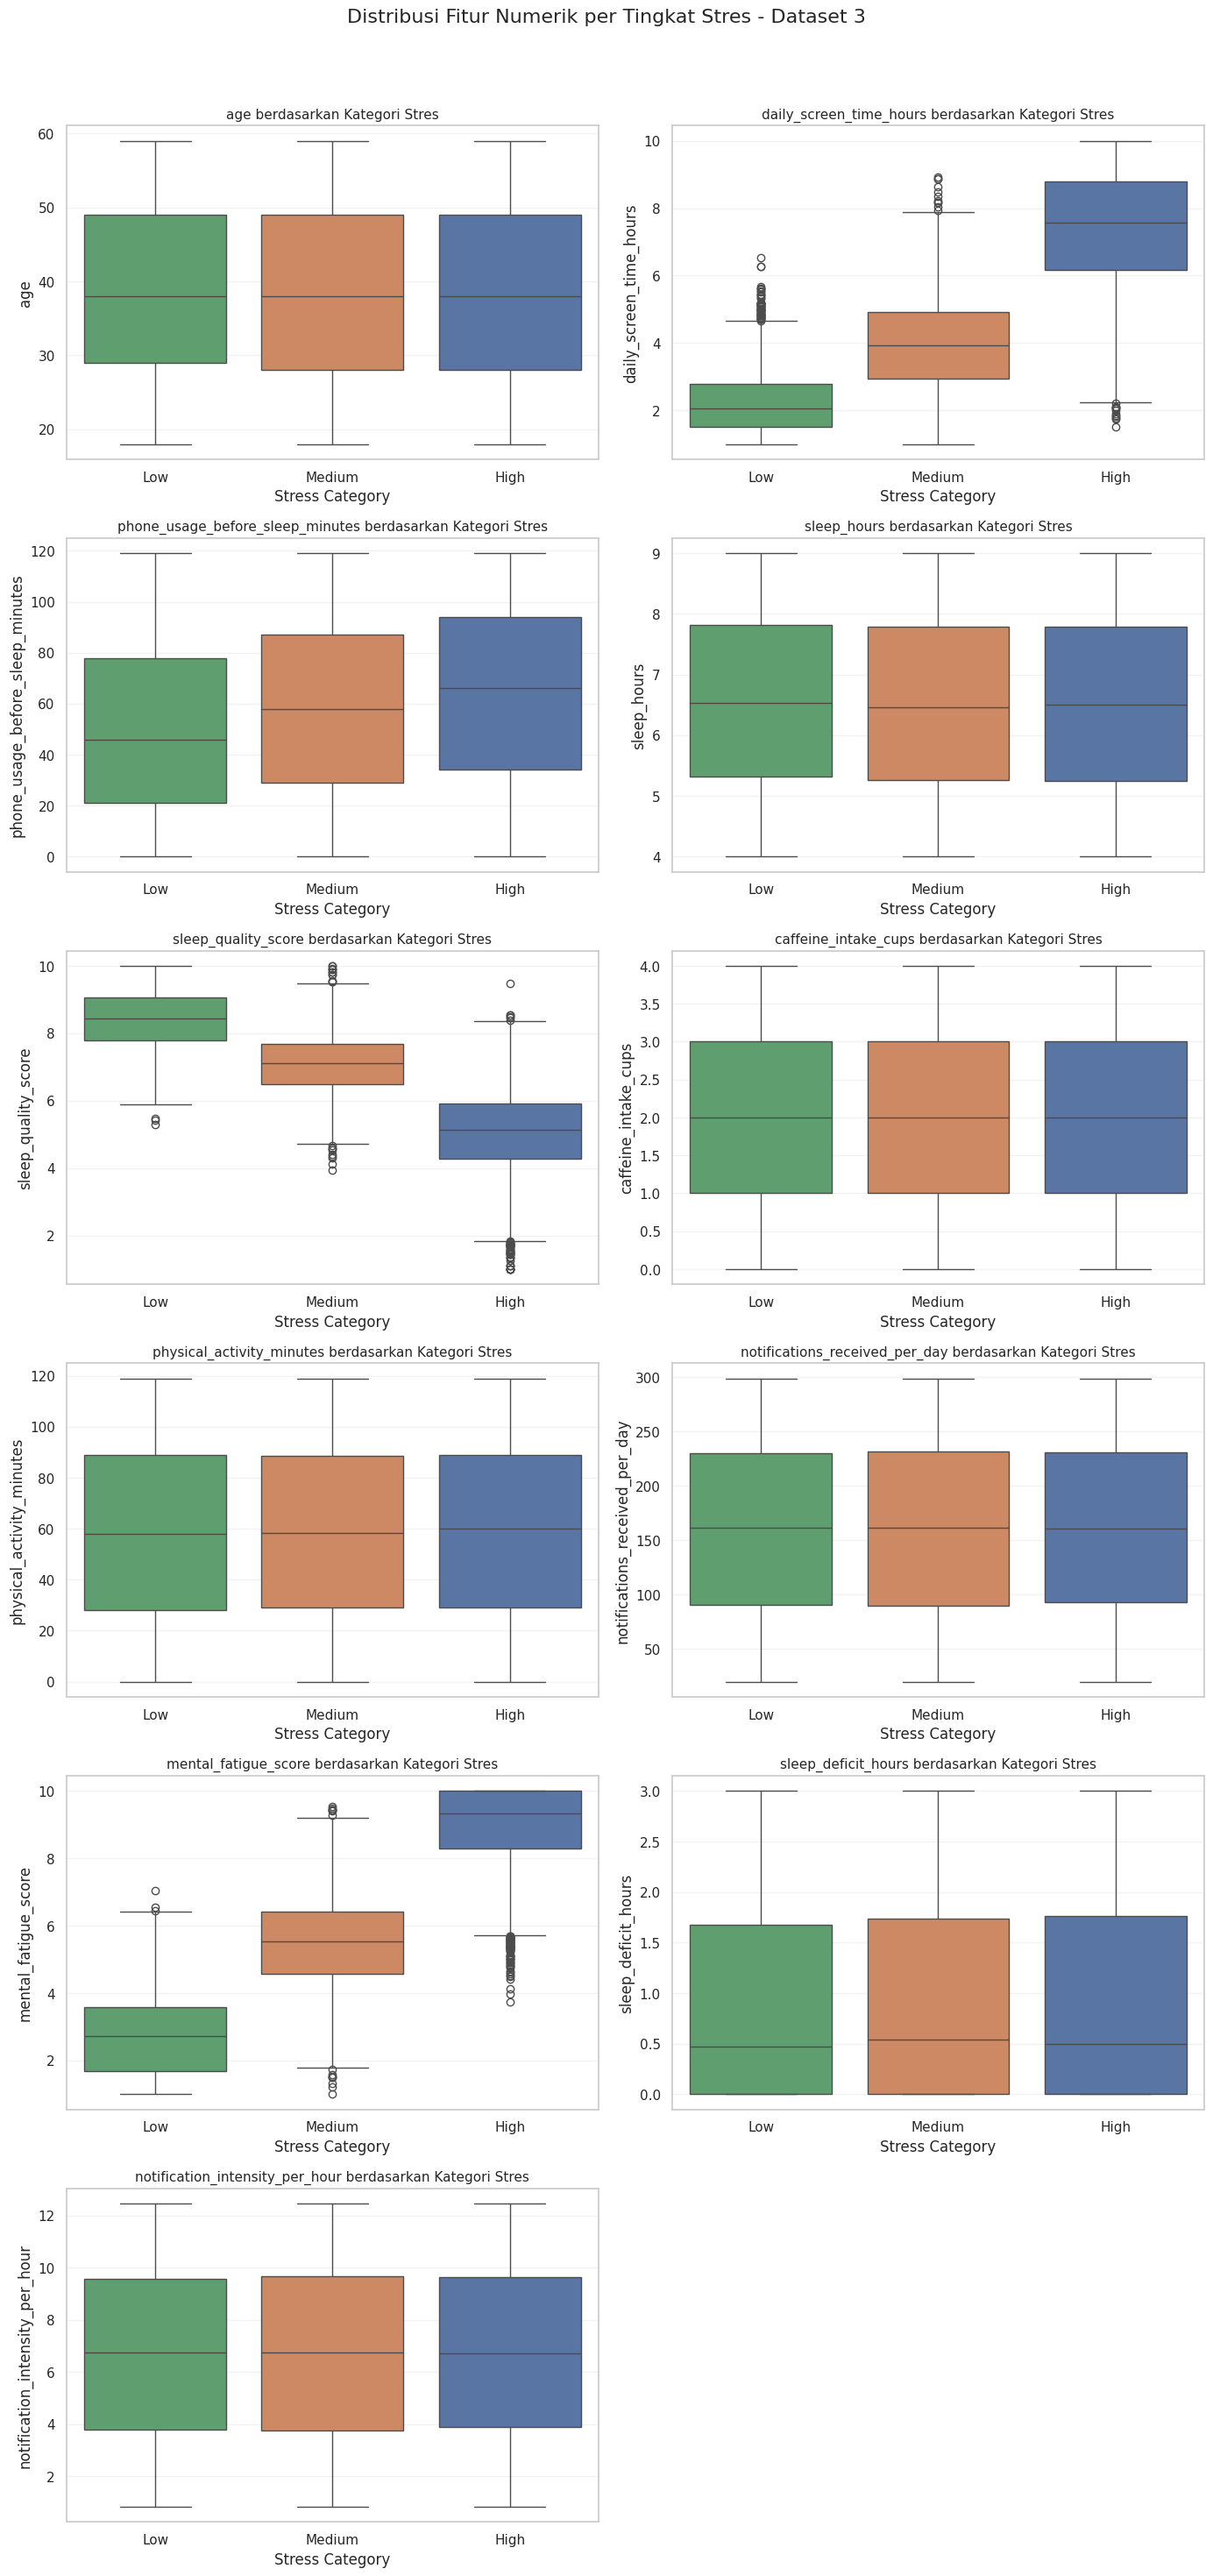

In [249]:
# ============================================================
# 8. EDA : Bivariate Analysis - DISTRIBUSI KOLOM NUMERIK TERHADAP KATEGORI STRES
# ============================================================
# Warna untuk tiap kategori
stress_order = ['low', 'medium', 'high']
stress_palette = ['#55A868', '#DD8452', '#4C72B0']

# Ambil hanya kolom numerik yang memang layak dibandingkan dengan stress_category
exclude_cols = ['user_id', 'stress_level', 'stress_target', 'poor_quality_and_short_sleep', 'high_phone_usage_low_sleep', 'high_screen_high_fatigue']

numeric_features = [
    col for col in df3_clean.select_dtypes(include=np.number).columns
    if col not in exclude_cols
]

print("Fitur numerik yang divisualisasikan:")
print(numeric_features)

# Atur jumlah subplot
n_cols = 2
n_rows = math.ceil(len(numeric_features) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4.8 * n_rows)
)

axes = axes.flatten()

# Buat boxplot untuk setiap fitur numerik
for i, col in enumerate(numeric_features):
    sns.boxplot(
        data=df3_clean,
        x='stress_category',
        y=col,
        order=stress_order,
        palette=stress_palette,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} berdasarkan Kategori Stres', fontsize=11)
    axes[i].set_xlabel('Stress Category')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', alpha=0.25)

    # Rapikan label x agar tampil High/Medium/Low
    axes[i].set_xticklabels(['Low', 'Medium', 'High'])

# Hapus subplot kosong jika jumlah fitur ganjil
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    'Distribusi Fitur Numerik per Tingkat Stres - Dataset 3',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

**Insight :**
- Daily screen time meningkat jelas dari Low ke High stress. Kelompok High stress memiliki screen time harian paling tinggi, sehingga fitur ini terlihat cukup kuat membedakan tingkat stres.
- Phone usage before sleep juga cenderung meningkat pada kategori High stress. Artinya, penggunaan HP sebelum tidur berpotensi berkaitan dengan tingkat stres yang lebih tinggi.
- Sleep quality score menurun dari Low ke High stress. Kelompok High stress memiliki kualitas tidur paling rendah, sehingga kualitas tidur menjadi indikator penting.
- Mental fatigue score meningkat sangat jelas pada High stress. Ini salah satu fitur yang paling kuat membedakan kategori stres.
- Sleep hours, caffeine intake, physical activity, notifications, sleep deficit, dan notification intensity tidak menunjukkan perbedaan yang terlalu kuat antar kategori stres.
- Age relatif mirip di semua kategori, sehingga usia bukan pembeda utama pada dataset ini.

**Fitur yang paling terlihat membedakan tingkat stres adalah:**
- daily_screen_time_hours
- phone_usage_before_sleep_minutes
- sleep_quality_score
- mental_fatigue_score



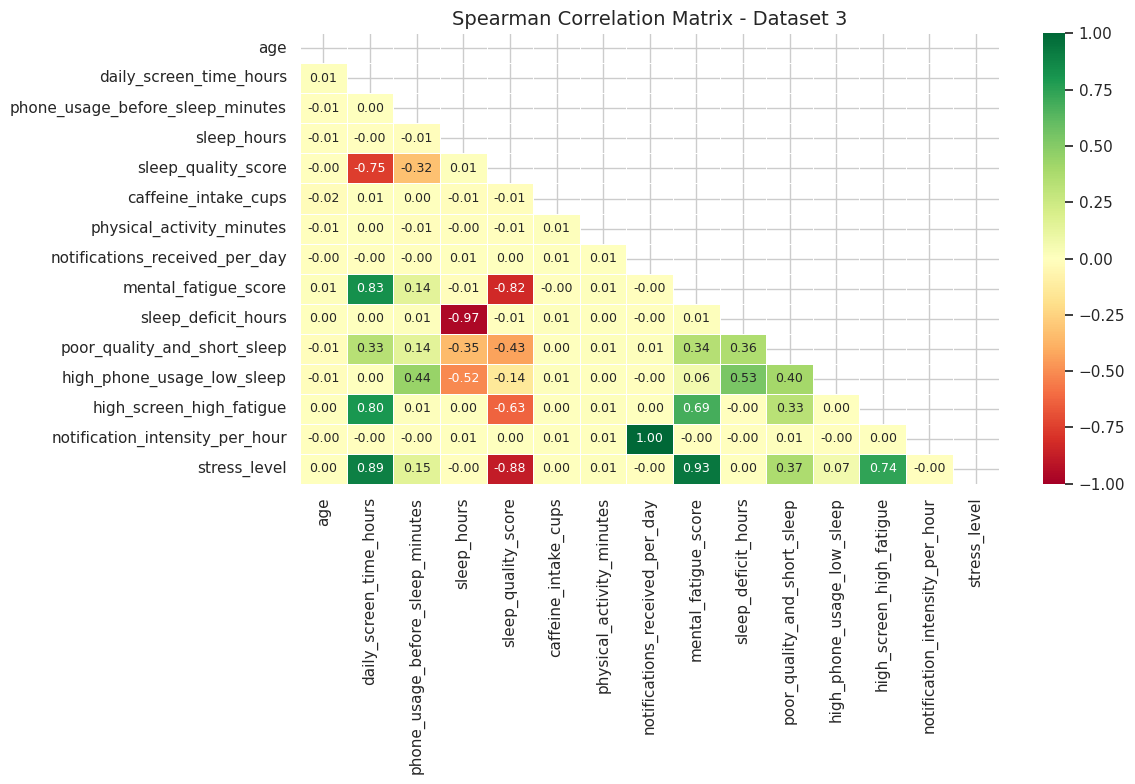


Korelasi fitur dengan stress_level:


,feature,spearman_correlation
0,mental_fatigue_score,0.930688
1,daily_screen_time_hours,0.893799
2,sleep_quality_score,-0.882255
3,high_screen_high_fatigue,0.741261
4,poor_quality_and_short_sleep,0.373136
5,phone_usage_before_sleep_minutes,0.153525
6,high_phone_usage_low_sleep,0.066389
7,physical_activity_minutes,0.008204
8,caffeine_intake_cups,0.004239
9,sleep_hours,-0.004185


In [250]:
# ============================================================
# 8. EDA : KORELASI FITUR NUMERIK DENGAN TINGKAT STRES
# ============================================================

exclude_cols = ['user_id', 'stress_level', 'stress_target']

numeric_features = [
    col for col in df3_clean.select_dtypes(include=np.number).columns
    if col not in exclude_cols
]

# Kolom target numerik yang digunakan untuk analisis korelasi
target_col = 'stress_level'

# Buat data khusus korelasi
corr_data = df3_clean[numeric_features + [target_col]].copy()

# Hitung korelasi Spearman
corr_matrix = corr_data.corr(method='spearman')

# Visualisasi heatmap korelasi
plt.figure(figsize=(12, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={'size': 9}
)

plt.title('Spearman Correlation Matrix - Dataset 3', fontsize=14)
plt.tight_layout()
plt.show()

# Tampilkan fitur yang paling berkorelasi dengan stress_level
print("\nKorelasi fitur dengan stress_level:")
corr_with_target = (
    corr_matrix[target_col]
    .drop(target_col)
    .sort_values(key=abs, ascending=False)
)

display(corr_with_target.reset_index().rename(
    columns={
        'index': 'feature',
        target_col: 'spearman_correlation'
    }
))


**Insight:**
- mental_fatigue_score memiliki korelasi positif paling kuat dengan stress_level, yaitu sekitar 0.93. Artinya, semakin tinggi kelelahan mental, semakin tinggi tingkat stres.
- daily_screen_time_hours juga memiliki korelasi positif kuat dengan stress_level, sekitar 0.89. Ini menunjukkan screen time harian tinggi berkaitan dengan stres lebih tinggi.
- sleep_quality_score memiliki korelasi negatif kuat dengan stress_level, sekitar -0.88. Artinya, semakin rendah kualitas tidur, semakin tinggi tingkat stres.
- high_screen_high_fatigue juga berkorelasi cukup kuat dengan stres, sekitar 0.74, sehingga fitur hasil feature engineering ini cukup informatif.
- phone_usage_before_sleep_minutes korelasinya lemah terhadap stress_level, sekitar 0.15, jadi pengaruhnya tidak sekuat screen time atau mental fatigue.
- Age, caffeine intake, physical activity, notifications, sleep hours, dan notification intensity hampir tidak berkorelasi langsung dengan stress_level.

**Fitur yang paling kuat berkaitan dengan tingkat stres adalah:**
- mental_fatigue_score
- daily_screen_time_hours
- sleep_quality_score
- high_screen_high_fatigue


Distribusi gender terhadap stress_category:


stress_category,low,medium,high
gender,,,
Female,18.72,27.70,53.59
Male,17.71,28.13,54.16
Other,16.24,28.38,55.38


<Figure size 900x500 with 0 Axes>

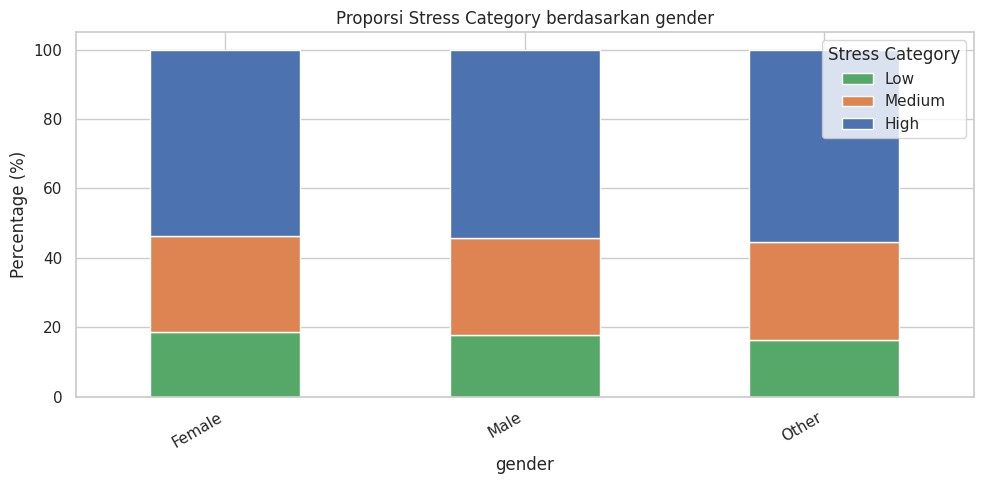


Distribusi occupation terhadap stress_category:


stress_category,low,medium,high
occupation,,,
Designer,18.81,29.40,51.79
Doctor,19.77,25.49,54.73
Freelancer,18.46,29.35,52.19
Manager,17.07,27.83,55.10
Researcher,18.51,28.25,53.24
Software Engineer,17.42,27.80,54.77
Student,15.91,26.97,57.12
Teacher,19.20,28.49,52.31


<Figure size 900x500 with 0 Axes>

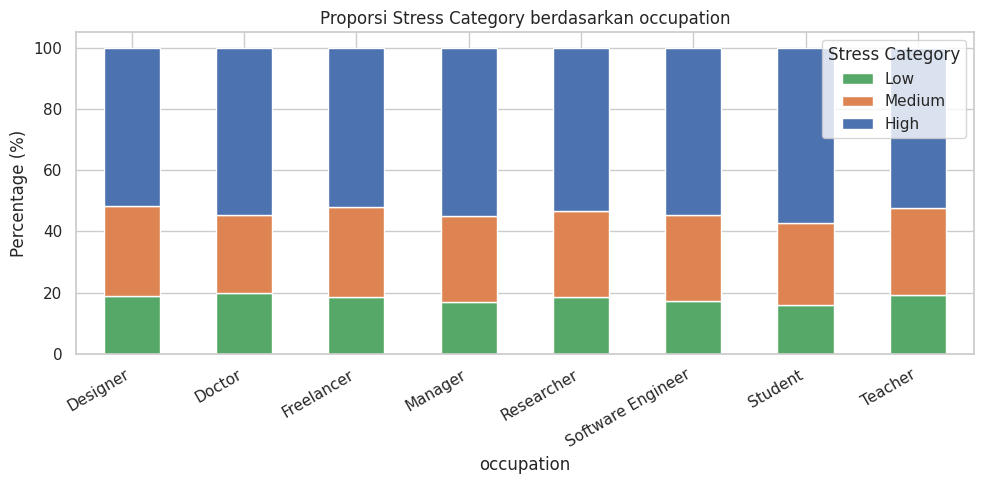


Distribusi sleep_duration_category terhadap stress_category:


stress_category,low,medium,high
sleep_duration_category,,,
ideal,18.20,28.04,53.76
long,19.04,27.59,53.37
short,17.60,28.00,54.39


<Figure size 900x500 with 0 Axes>

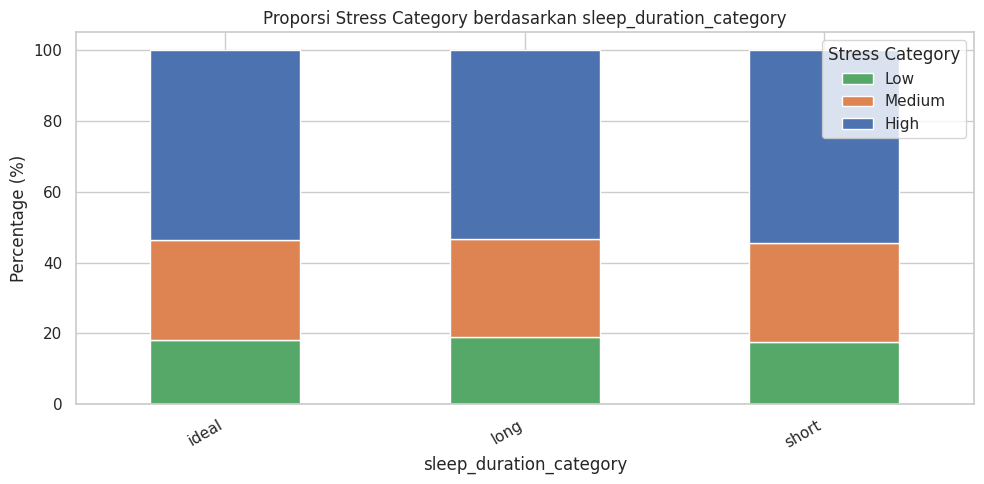


Distribusi sleep_quality_category terhadap stress_category:


stress_category,low,medium,high
sleep_quality_category,,,
good,60.80,36.44,2.77
moderate,5.78,37.08,57.14
poor,0.00,0.99,99.01


<Figure size 900x500 with 0 Axes>

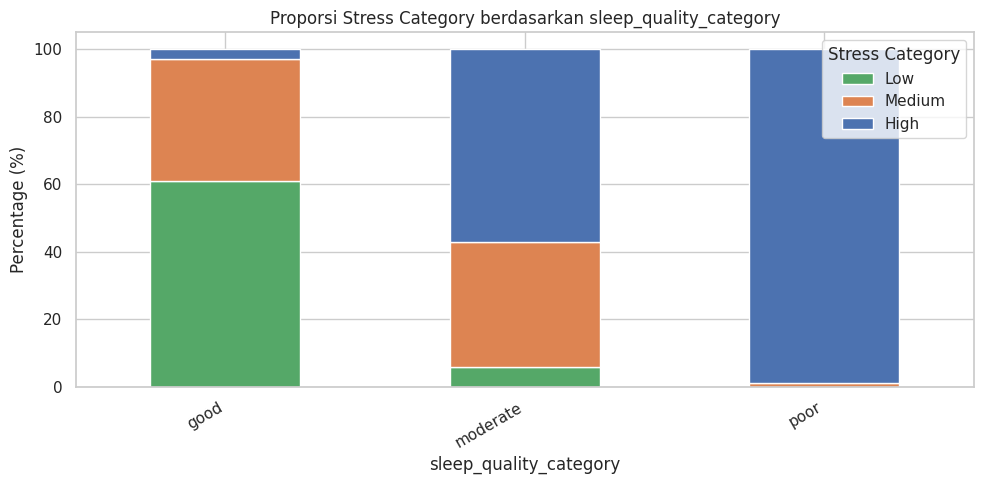


Distribusi phone_usage_before_sleep_category terhadap stress_category:


stress_category,low,medium,high
phone_usage_before_sleep_category,,,
high,13.70,27.20,59.09
low,24.71,28.17,47.12
medium,20.25,29.11,50.64


<Figure size 900x500 with 0 Axes>

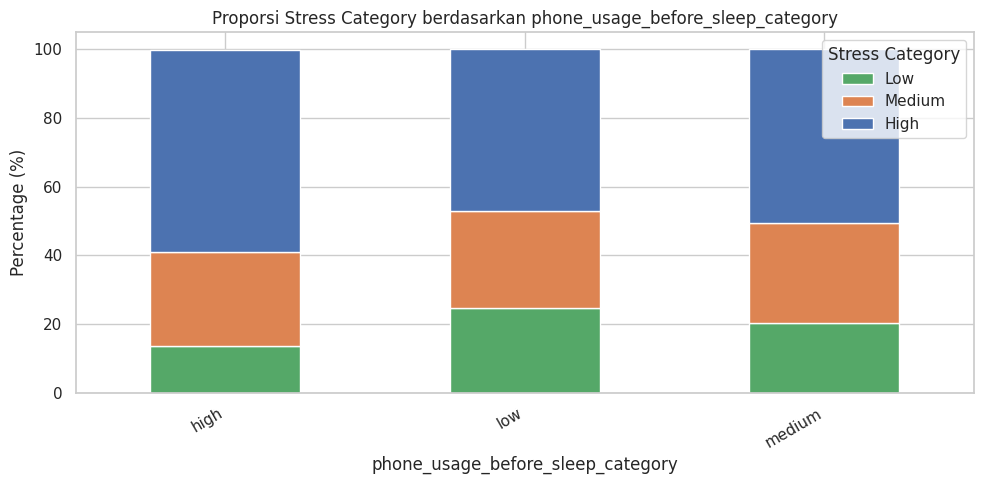


Distribusi daily_screen_time_category terhadap stress_category:


stress_category,low,medium,high
daily_screen_time_category,,,
high,0.00,1.29,98.71
low,51.54,43.76,4.70
moderate,3.07,38.53,58.41


<Figure size 900x500 with 0 Axes>

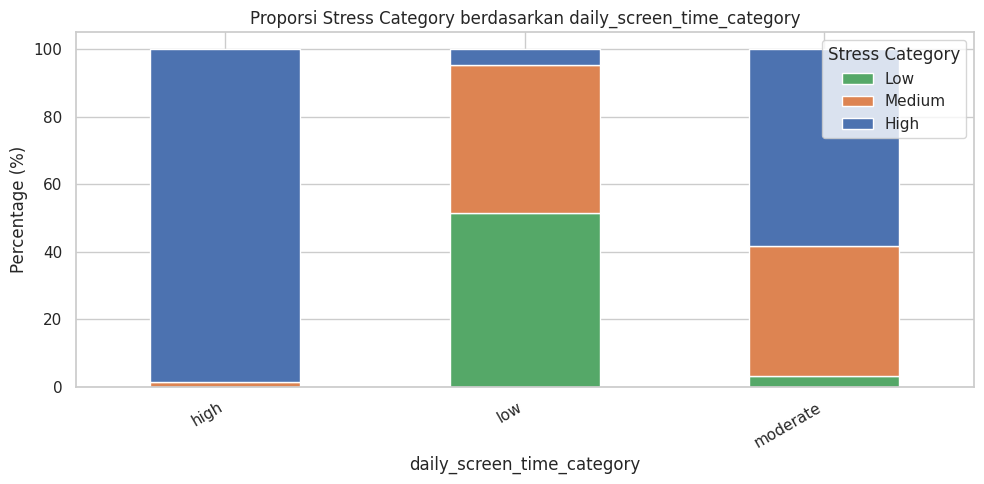


Distribusi poor_quality_and_short_sleep terhadap stress_category:


stress_category,low,medium,high
poor_quality_and_short_sleep,,,
0,20.17,30.95,48.88
1,0.00,1.12,98.88


<Figure size 900x500 with 0 Axes>

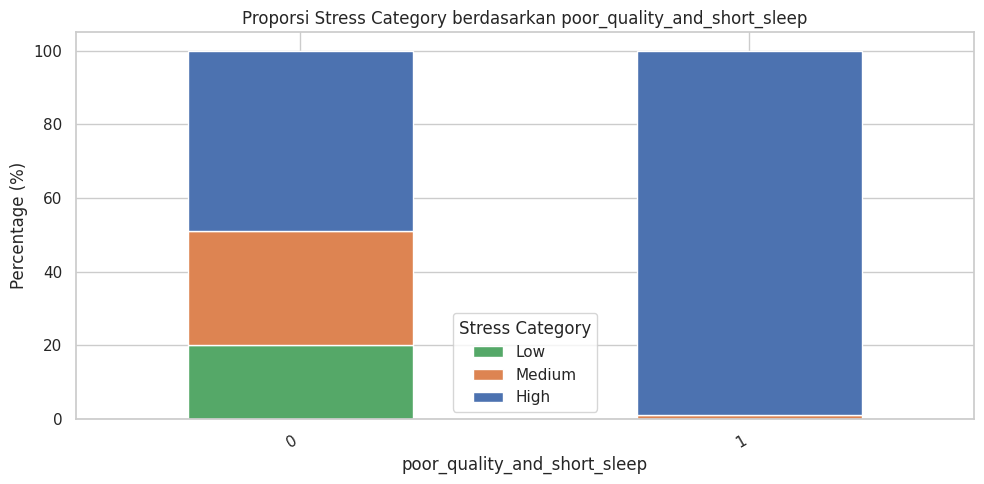


Distribusi high_phone_usage_low_sleep terhadap stress_category:


stress_category,low,medium,high
high_phone_usage_low_sleep,,,
0,19.35,28.06,52.59
1,13.24,27.41,59.35


<Figure size 900x500 with 0 Axes>

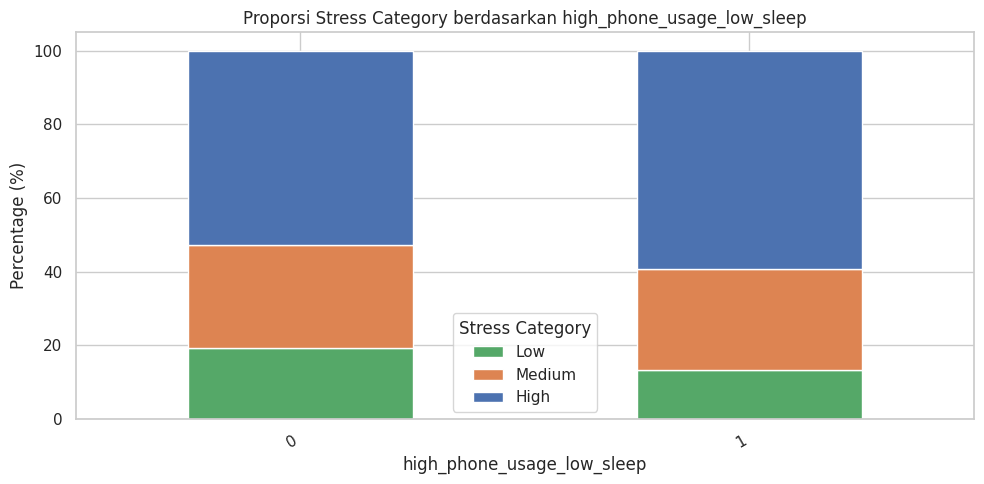


Distribusi high_screen_high_fatigue terhadap stress_category:


stress_category,low,medium,high
high_screen_high_fatigue,,,
0,26.71,40.98,32.32
1,0.00,0.35,99.65


<Figure size 900x500 with 0 Axes>

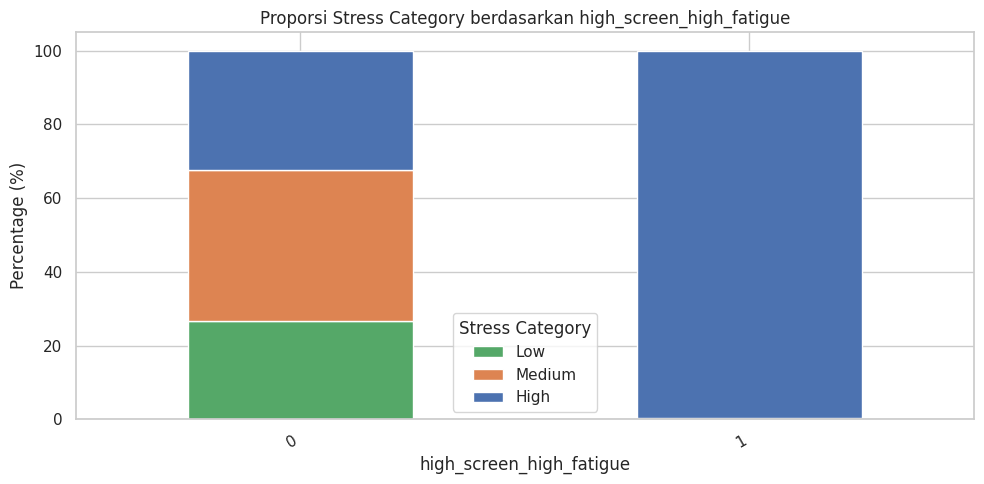

In [251]:
# ============================================================
# 8. EDA : BIvariate Analysis - ANALISIS FITUR KATEGORIKAL TERHADAP TINGKAT STRES
# ============================================================

categorical_features = ['gender', 'occupation', 'sleep_duration_category', 'sleep_quality_category', 'phone_usage_before_sleep_category', 'daily_screen_time_category','poor_quality_and_short_sleep', 'high_phone_usage_low_sleep', 'high_screen_high_fatigue']
stress_order = ['low', 'medium', 'high']

for col in categorical_features:
    if col in df3_clean.columns:
        print(f"\nDistribusi {col} terhadap stress_category:")

        cat_stress_table = pd.crosstab(
            df3_clean[col],
            df3_clean['stress_category'],
            normalize='index'
        )[stress_order] * 100

        cat_stress_table = cat_stress_table.round(2)

        display(cat_stress_table)

        plt.figure(figsize=(9, 5))

        cat_stress_table.plot(
            kind='bar',
            stacked=True,
            figsize=(10, 5),
            color=['#55A868', '#DD8452', '#4C72B0']
        )

        plt.title(f'Proporsi Stress Category berdasarkan {col}')
        plt.xlabel(col)
        plt.ylabel('Percentage (%)')
        plt.xticks(rotation=30, ha='right')
        plt.legend(title='Stress Category', labels=['Low', 'Medium', 'High'])
        plt.tight_layout()
        plt.show()

In [252]:
# ============================================================
# 8. EDA : KOLOM KATEGORIKAL - STATISTICAL TEST TERHADAP STRESS CATEGORY
# ============================================================

from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# Fungsi untuk menghitung Cramer's V
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

cat_test_results = []

for col in categorical_features:
    if col in df3_clean.columns:
        print(f"\n{'='*70}")
        print(f"Analisis kategorikal: {col} vs stress_category")
        print(f"{'='*70}")

        # Tabel frekuensi
        freq_table = df3_clean[col].value_counts().reset_index()
        freq_table.columns = [col, 'count']
        freq_table['percentage'] = (
            freq_table['count'] / len(df3_clean) * 100
        ).round(2)

        print("\nDistribusi kategori:")
        display(freq_table)

        # Crosstab jumlah
        crosstab_count = pd.crosstab(
            df3_clean[col],
            df3_clean['stress_category']
        )

        print("\nCrosstab jumlah:")
        display(crosstab_count)

        # Crosstab persentase per kategori
        crosstab_pct = pd.crosstab(
            df3_clean[col],
            df3_clean['stress_category'],
            normalize='index'
        ) * 100

        crosstab_pct = crosstab_pct.round(2)

        print("\nCrosstab persentase per kategori:")
        display(crosstab_pct)

        # Chi-Square Test
        chi2, p_value, dof, expected = chi2_contingency(crosstab_count)

        # Cramer's V
        cv = cramers_v(crosstab_count)

        cat_test_results.append({
            'feature': col,
            'chi2_statistic': round(chi2, 3),
            'p_value': p_value,
            'cramers_v': round(cv, 3),
            'interpretation': 'Significant' if p_value < 0.05 else 'Not significant'
        })

cat_test_results = pd.DataFrame(cat_test_results)

print("\nRingkasan hasil uji statistik kategorikal:")
display(cat_test_results)


Analisis kategorikal: gender vs stress_category

Distribusi kategori:


,gender,count,percentage
0,Male,7234,48.23
1,Female,7181,47.87
2,Other,585,3.90



Crosstab jumlah:


stress_category,high,low,medium
gender,,,
Female,3848,1344,1989
Male,3918,1281,2035
Other,324,95,166



Crosstab persentase per kategori:


...

stress_category,high,low,medium
high_screen_high_fatigue,,,
0,3291,2720,4173
1,4799,0,17



Crosstab persentase per kategori:


stress_category,high,low,medium
high_screen_high_fatigue,,,
0,32.32,26.71,40.98
1,99.65,0.00,0.35



Ringkasan hasil uji statistik kategorikal:


,feature,chi2_statistic,p_value,cramers_v,interpretation
0,gender,3.967,4.105171e-01,0.011,Not significant
1,occupation,27.378,1.718514e-02,0.030,Significant
2,sleep_duration_category,2.958,5.649171e-01,0.010,Not significant
3,sleep_quality_category,9621.516,0.000000e+00,0.566,Significant
4,phone_usage_before_sleep_category,259.117,7.068311e-55,0.093,Significant
5,daily_screen_time_category,10610.195,0.000000e+00,0.595,Significant
6,poor_quality_and_short_sleep,1372.535,9.072996e-299,0.302,Significant
7,high_phone_usage_low_sleep,69.868,6.734905e-16,0.068,Significant
8,high_screen_high_fatigue,5966.459,0.000000e+00,0.631,Significant


**Insight:**
- Gender tidak menunjukkan perbedaan pola stres yang besar. Proporsi high stress pada Female, Male, dan Other relatif mirip, sekitar 53–55%, sehingga gender kemungkinan bukan pembeda utama tingkat stres.
- Occupation menunjukkan sedikit perbedaan, tetapi tidak terlalu ekstrem. Kelompok Student memiliki proporsi high stress tertinggi, yaitu sekitar 57,12%, sedangkan Designer paling rendah sekitar 51,79%. Ini menunjukkan pekerjaan/status aktivitas bisa menjadi faktor segmentasi, tetapi pengaruhnya tidak sekuat fitur seperti sleep quality atau screen time.
- Sleep duration category tidak terlalu membedakan stres. Proporsi high stress pada short, ideal, dan long sleep masih mirip, sekitar 53–54%. Artinya, durasi tidur saja belum cukup kuat untuk membedakan tingkat stres.
- Sleep quality category sangat membedakan tingkat stres. Pada kategori low_quality, proporsi high stress sangat dominan, sekitar 99,01%, sedangkan pada high_quality, high stress hanya sekitar 2,77%. Ini menjadi salah satu fitur kategorikal paling penting.
- Phone usage before sleep category juga menunjukkan pola yang cukup jelas. Kelompok high_phone_usage memiliki high stress rate sekitar 59,09%, lebih tinggi dibanding low_phone_usage sekitar 47,12%. Jadi penggunaan HP sebelum tidur dapat menjadi indikator risiko tambahan.

**Fitur kategorikal yang paling kuat untuk menjelaskan perbedaan kategori stres adalah:**
- sleep_quality_category
- phone_usage_before_sleep_category
- occupation, terutama kelompok Student, tetapi efeknya lebih lemah

Sedangkan gender dan sleep_duration_category tidak terlalu kuat sebagai pembeda utama.

Top fitur berdasarkan Mutual Information:


,feature,mutual_info_score
10,mental_fatigue_score,0.686039
3,daily_screen_time_hours,0.519460
6,sleep_quality_score,0.490119
14,daily_screen_time_category,0.429269
12,sleep_quality_category,0.365521
18,high_screen_high_fatigue,0.256749
16,poor_quality_and_short_sleep,0.059718
4,phone_usage_before_sleep_minutes,0.012769
13,phone_usage_before_sleep_category,0.008584
0,age,0.005237


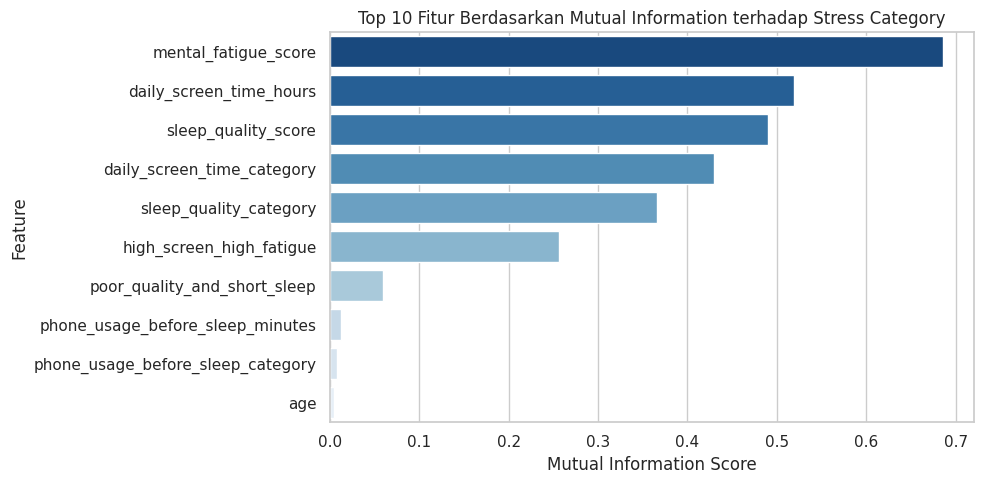

In [253]:
# ============================================================
# 8. EDA :  FEATURE IMPORTANCE AWAL DENGAN MUTUAL INFORMATION
# ============================================================

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# Buat salinan data agar df3_clean tetap aman
df_mi = df3_clean.copy()

# Kolom yang tidak dipakai sebagai fitur
drop_cols = [
    'stress_level',
    'stress_category',
    'stress_target'
]

feature_cols = [
    col for col in df_mi.columns
    if col not in drop_cols
]

# Pisahkan fitur dan target
X_mi = df_mi[feature_cols].copy()
y_mi = df_mi['stress_category'].astype(str)

# Encode kolom kategorikal, misalnya gender dan occupation
cat_cols = X_mi.select_dtypes(include='object').columns.tolist()

if len(cat_cols) > 0:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_mi[cat_cols] = encoder.fit_transform(X_mi[cat_cols].astype(str))

# Isi missing value jika masih ada
X_mi = X_mi.fillna(0)

# Encode target stress_category menjadi angka
label_encoder = LabelEncoder()
y_mi_encoded = label_encoder.fit_transform(y_mi)

# Tandai fitur kategorikal agar mutual information membacanya sebagai fitur diskrit
discrete_features = [col in cat_cols for col in X_mi.columns]

# Hitung mutual information
mi_scores = mutual_info_classif(
    X_mi,
    y_mi_encoded,
    discrete_features=discrete_features,
    random_state=42
)

# Simpan hasil ke dataframe
mi_df = pd.DataFrame({
    'feature': X_mi.columns,
    'mutual_info_score': mi_scores
}).sort_values(by='mutual_info_score', ascending=False)

print("Top fitur berdasarkan Mutual Information:")
display(mi_df.head(10))

# Visualisasi top 10 fitur
plt.figure(figsize=(10, 5))

sns.barplot(
    data=mi_df.head(10),
    x='mutual_info_score',
    y='feature',
    palette='Blues_r'
)

plt.title('Top 10 Fitur Berdasarkan Mutual Information terhadap Stress Category')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Insight:**
- mental_fatigue_score menjadi fitur paling informatif terhadap stress_category, dengan skor Mutual Information tertinggi yaitu sekitar 0,686.
daily_screen_time_hours juga sangat informatif, dengan skor sekitar 0,519, sehingga screen time harian berperan penting dalam membedakan kategori stres.
- sleep_quality_score termasuk fitur utama, dengan skor sekitar 0,490. Ini konsisten dengan hasil EDA sebelumnya bahwa kualitas tidur rendah berkaitan dengan stres tinggi.
- Fitur hasil kategorisasi seperti daily_screen_time_category dan sleep_quality_category juga cukup informatif, tetapi nilainya masih di bawah fitur numerik aslinya.
- Fitur hasil feature engineering high_screen_high_fatigue cukup berguna, karena menangkap kombinasi risiko antara screen time tinggi dan fatigue tinggi.
- phone_usage_before_sleep_minutes, phone_usage_before_sleep_category, dan age memiliki skor sangat rendah, sehingga kurang kuat sebagai fitur utama untuk mendeteksi kategori stres.

**Fitur paling penting untuk mendeteksi kategori stres adalah:**

- mental_fatigue_score
- daily_screen_time_hours
- sleep_quality_score
- daily_screen_time_category
- sleep_quality_category

Kategori stres pada dataset ini paling banyak dipengaruhi oleh kelelahan mental, screen time harian, dan kualitas tidur. (dengan metode mutual information)

In [254]:
# ============================================================
# 8. EDA : RINGKASAN FITUR NUMERIK ASLI DAN FEATURE ENGINEERING
# ============================================================

sleep_col = 'sleep_hours' if 'sleep_hours' in df3_clean.columns else 'sleep_duration_hours'

numeric_focus = [
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    sleep_col,
    'sleep_quality_score',
    'caffeine_intake_cups',
    'physical_activity_minutes',
    'notifications_received_per_day',
    'mental_fatigue_score',
    'sleep_deficit_hours',
    'notification_intensity_per_hour',
    'stress_level'
]

numeric_focus = [col for col in numeric_focus if col in df3_clean.columns]

stress_order = ['low', 'medium', 'high']

stress_group_summary = (
    df3_clean
    .groupby('stress_category')[numeric_focus]
    .mean()
    .reindex(stress_order)
    .round(2)
)

display(stress_group_summary)

,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_hours,sleep_quality_score,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,sleep_deficit_hours,notification_intensity_per_hour,stress_level
stress_category,,,,,,,,,,,
low,2.24,50.47,6.54,8.42,2.0,58.68,161.39,2.72,0.88,6.72,2.64
medium,3.95,58.58,6.50,7.10,2.0,58.78,160.61,5.51,0.91,6.69,5.51
high,7.40,63.40,6.51,5.07,2.0,59.51,160.87,8.97,0.90,6.70,9.20


**Insight:**
- Daily screen time meningkat sangat jelas dari kategori low ke high stress: low 2,24 jam, medium 3,95 jam, dan high 7,40 jam. Ini menunjukkan screen time harian menjadi salah satu pembeda utama tingkat stres.
- Mental fatigue score juga meningkat tajam dari low 2,72, medium 5,51, hingga high 8,97. Artinya, semakin tinggi kelelahan mental, semakin tinggi kategori stres.
- Sleep quality score menurun jelas dari low 8,42, medium 7,10, menjadi high 5,07. Ini menunjukkan kualitas tidur yang lebih rendah berkaitan dengan stres yang lebih tinggi.
- Phone usage before sleep naik, tetapi perbedaannya tidak setajam screen time dan mental fatigue: low 50,47 menit, medium 58,58 menit, dan high 63,40 menit. Jadi fitur ini tetap relevan, tetapi bukan faktor paling kuat.
- Sleep hours, caffeine intake, physical activity, notifications, sleep deficit, dan notification intensity relatif mirip antar kategori stres, sehingga belum terlihat sebagai pembeda utama.
Insight Utama

**Fitur yang paling membedakan kategori stres adalah:**
- mental_fatigue_score
- daily_screen_time_hours
- sleep_quality_score
- phone_usage_before_sleep_minutes, tetapi pengaruhnya lebih lemah

Secara umum, kelompok high stress memiliki pola: screen time lebih tinggi, mental fatigue lebih tinggi, kualitas tidur lebih rendah, dan penggunaan HP sebelum tidur lebih lama.

**Poin penting fitur dari keseluruhan EDA:**
- mental_fatigue_score → fitur paling kuat; makin tinggi fatigue, makin tinggi stres.
- daily_screen_time_hours → sangat penting; high stress punya screen time paling tinggi.
- sleep_quality_score → sangat penting; kualitas tidur makin rendah, stres makin tinggi.
- sleep_quality_category → kuat untuk membedakan low/medium/high stress.
- daily_screen_time_category → cukup penting sebagai versi kategori dari screen time.
- high_screen_high_fatigue → fitur engineering yang berguna karena menangkap kombinasi screen time tinggi + fatigue tinggi.
- phone_usage_before_sleep_minutes → relevan, tapi kekuatannya lebih sebagai fitur pendukung.

---
## 9. Explanatory Analysis — Visualisasi untuk Menjawab Pertanyaan Bisnis

Membuat visualisasi yang lebih langsung menjawab pertanyaan bisnis, bukan hanya mengeksplorasi data.

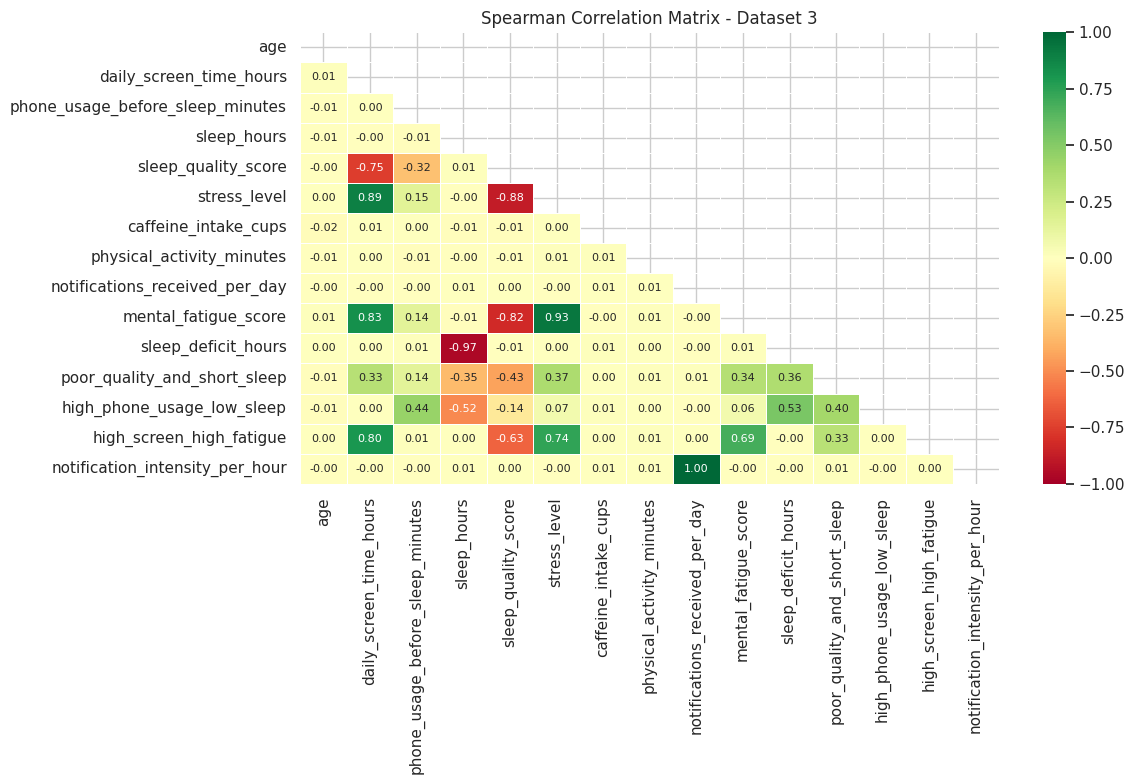

,feature,spearman_correlation
0,mental_fatigue_score,0.930688
1,daily_screen_time_hours,0.893799
2,sleep_quality_score,-0.882255
3,high_screen_high_fatigue,0.741261
4,poor_quality_and_short_sleep,0.373136
5,phone_usage_before_sleep_minutes,0.153525
6,high_phone_usage_low_sleep,0.066389
7,physical_activity_minutes,0.008204
8,caffeine_intake_cups,0.004239
9,sleep_hours,-0.004185


,feature,mutual_info_score
10,mental_fatigue_score,0.686039
3,daily_screen_time_hours,0.519460
6,sleep_quality_score,0.490119
14,daily_screen_time_category,0.429269
12,sleep_quality_category,0.365521
18,high_screen_high_fatigue,0.256749
16,poor_quality_and_short_sleep,0.059718
4,phone_usage_before_sleep_minutes,0.012769
13,phone_usage_before_sleep_category,0.008584
0,age,0.005237


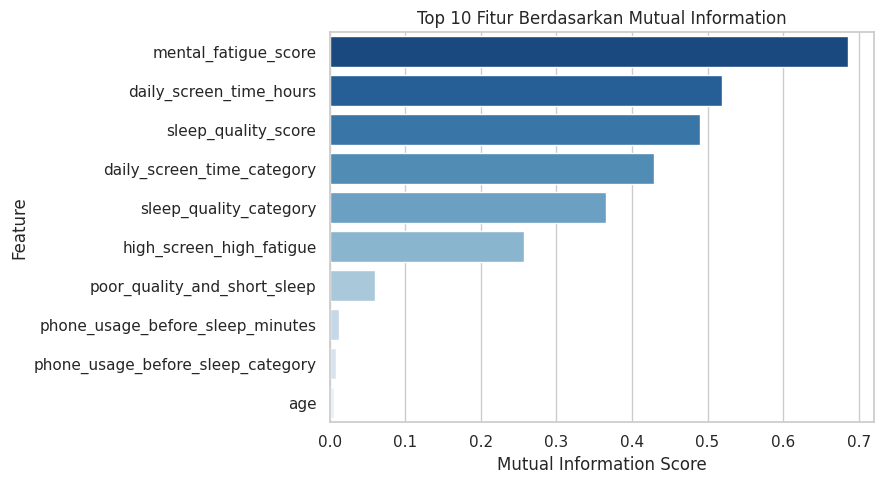

In [255]:
# ============================================================
# 9. EXPLANATORY ANALYSIS : Q1 - Faktor yang paling berkaitan dengan tingkat stres
# ============================================================

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.feature_selection import mutual_info_classif

stress_order = ['low', 'medium', 'high']
target_col = 'stress_category'

# -----------------------------
# 1A. Korelasi Spearman
# -----------------------------
numeric_cols = df3_clean.select_dtypes(include=np.number).columns.tolist()

exclude_cols = ['user_id', 'stress_target']
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

corr_matrix = df3_clean[numeric_cols].corr(method='spearman')

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={'size': 8}
)

plt.title('Spearman Correlation Matrix - Dataset 3')
plt.tight_layout()
plt.show()

if 'stress_level' in corr_matrix.columns:
    corr_target = (
        corr_matrix['stress_level']
        .drop('stress_level')
        .sort_values(key=abs, ascending=False)
        .reset_index()
    )
    corr_target.columns = ['feature', 'spearman_correlation']
    display(corr_target.head(10))


# -----------------------------
# 1B. Mutual Information
# -----------------------------
df_mi = df3_clean.copy()

drop_cols = ['user_id', 'stress_level', 'stress_category', 'stress_target']
feature_cols = [col for col in df_mi.columns if col not in drop_cols]

X_mi = df_mi[feature_cols].copy()
y_mi = df_mi[target_col].astype(str)

cat_cols = X_mi.select_dtypes(include='object').columns.tolist()

if len(cat_cols) > 0:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_mi[cat_cols] = encoder.fit_transform(X_mi[cat_cols].astype(str))

X_mi = X_mi.fillna(0)

label_encoder_mi = LabelEncoder()
y_mi_encoded = label_encoder_mi.fit_transform(y_mi)

discrete_features = [col in cat_cols for col in X_mi.columns]

mi_scores = mutual_info_classif(
    X_mi,
    y_mi_encoded,
    discrete_features=discrete_features,
    random_state=42
)

mi_df = pd.DataFrame({
    'feature': X_mi.columns,
    'mutual_info_score': mi_scores
}).sort_values('mutual_info_score', ascending=False)

display(mi_df.head(10))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=mi_df.head(10),
    x='mutual_info_score',
    y='feature',
    palette='Blues_r'
)
plt.title('Top 10 Fitur Berdasarkan Mutual Information')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Insight:**
- mental_fatigue_score adalah **fitur paling kuat**, dengan korelasi positif sekitar 0,93 terhadap stress_level dan skor Mutual Information tertinggi sekitar 0,686.
- daily_screen_time_hours **juga sangat kuat**, dengan korelasi positif sekitar 0,89 dan Mutual Information sekitar 0,519.
- sleep_quality_score **memiliki hubungan negatif kuat**, dengan korelasi sekitar -0,88. Artinya, semakin rendah kualitas tidur, semakin tinggi tingkat stres.
- Fitur seperti age, sleep_hours, caffeine_intake_cups, dan physical_activity_minutes tidak menunjukkan hubungan kuat dengan tingkat stres pada output ini.

**Jawaban Pertanyaan Bisnis:**
  - Faktor yang paling berkaitan dengan tingkat stres pengguna adalah **mental fatigue, daily screen time, dan sleep quality.** Pengguna dengan tingkat stres tinggi cenderung memiliki **mental fatigue lebih tinggi, screen time harian lebih lama, dan kualitas tidur lebih rendah**

**Rekomendasi Bisnis:**
- Prioritaskan fitur mental fatigue, daily screen time, dan sleep quality untuk analisis lanjutan dan modeling pada pengembangan projek selanjutnya.
- Untuk rekomendasi produk pada pegembangan selanjutnya, aplikasi dapat memberi fokus pada monitoring mental fatigue, pengingat mengurangi screen time, dan edukasi sleep hygiene.
- Fitur high_screen_high_fatigue dapat digunakan sebagai indikator risiko tambahan untuk mendeteksi pengguna yang perlu diprioritaskan pada pengembangan aplikasi selanjutnya.

,daily_screen_time_hours,phone_usage_before_sleep_minutes,stress_level
stress_category,,,
low,2.24,50.47,2.64
medium,3.95,58.58,5.51
high,7.40,63.40,9.20


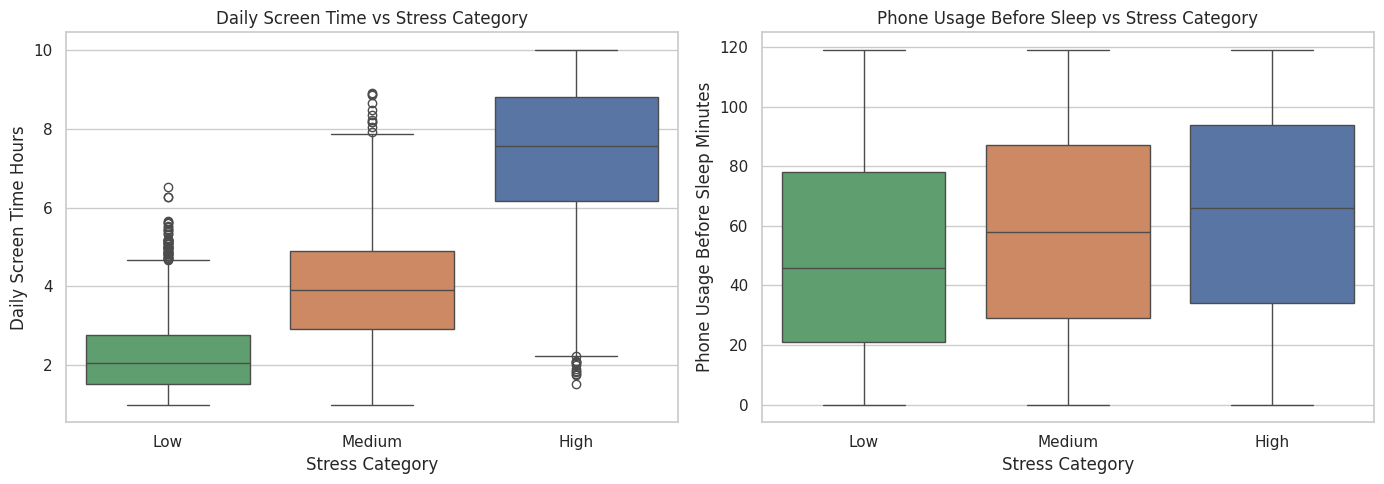

In [256]:
# ============================================================
# 9. EXPLANATORY ANALYSIS : Q2 - Screen time dan penggunaan HP sebelum tidur vs stres
# ============================================================

screen_phone_cols = [
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'stress_level'
]

screen_phone_cols = [col for col in screen_phone_cols if col in df3_clean.columns]

screen_phone_summary = (
    df3_clean
    .groupby(target_col)[screen_phone_cols]
    .mean()
    .reindex(stress_order)
    .round(2)
)

display(screen_phone_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df3_clean,
    x=target_col,
    y='daily_screen_time_hours',
    order=stress_order,
    palette=['#55A868', '#DD8452', '#4C72B0'],
    ax=axes[0]
)
axes[0].set_title('Daily Screen Time vs Stress Category')
axes[0].set_xlabel('Stress Category')
axes[0].set_ylabel('Daily Screen Time Hours')
axes[0].set_xticklabels(['Low', 'Medium', 'High'])

sns.boxplot(
    data=df3_clean,
    x=target_col,
    y='phone_usage_before_sleep_minutes',
    order=stress_order,
    palette=['#55A868', '#DD8452', '#4C72B0'],
    ax=axes[1]
)
axes[1].set_title('Phone Usage Before Sleep vs Stress Category')
axes[1].set_xlabel('Stress Category')
axes[1].set_ylabel('Phone Usage Before Sleep Minutes')
axes[1].set_xticklabels(['Low', 'Medium', 'High'])

plt.tight_layout()
plt.show()

**Insight:**
- Rata-rata daily screen time meningkat dari kategori Low ke High stress.
- Pada boxplot, kelompok High stress punya median screen time paling tinggi dan sebaran nilainya berada di rentang yang lebih tinggi dibanding Low dan Medium.
- Rata-rata phone usage before sleep juga meningkat dari kategori Low ke High stress, tetapi tidak setajam screen time:

**Jawaban Pertanyaan Bisnis :**
  - Ya, **screen time harian dan penggunaan ponsel sebelum tidur berkaitan dengan tingkat stres yang lebih tinggi**, terutama untuk daily_screen_time_hours. Hubungan screen time dengan stres terlihat lebih kuat dibanding penggunaan HP sebelum tidur.

**Rekomendasi Bisnis:**
- Aplikasi dapat memberi screen time reminder untuk pengguna dengan durasi screen time tinggi.
- Tambahkan fitur daily screen time monitoring sebagai indikator risiko stres.
- Untuk pengguna dengan penggunaan HP sebelum tidur tinggi, berikan rekomendasi seperti mengurangi penggunaan ponsel 30-60 menit sebelum tidur.
- Fokus utama intervensi/rekomendasii sebaiknya pada screen time harian, sedangkan phone usage before sleep digunakan sebagai sinyal tambahan.

stress_category,low,medium,high
sleep_quality_category,,,
poor,0.00,0.99,99.01
moderate,5.78,37.08,57.14
good,60.80,36.44,2.77


Chi-Square Test:
- Chi-square statistic : 9621.516
- p-value              : 0.00000
- Degrees of freedom   : 4


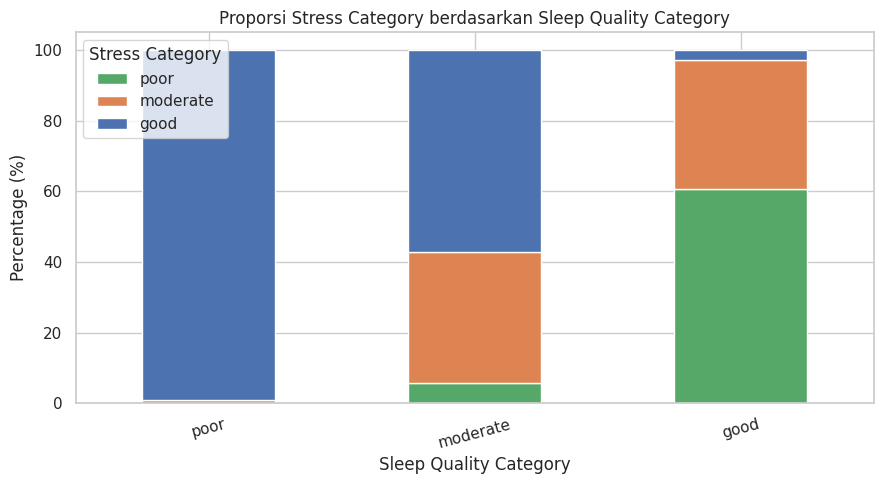

In [257]:
# ============================================================
# 9. EXPLANATORY ANALYSIS : Q3 - Kualitas tidur vs kategori stres
# ============================================================

from scipy.stats import chi2_contingency

# Buat kategori sleep quality jika belum ada
if 'sleep_quality_category' not in df3_clean.columns:
    df3_clean['sleep_quality_category'] = pd.cut(
        df3_clean['sleep_quality_score'],
        bins=[0, 4, 7, 10],
        labels=['poor (low_quality)', 'moderate (medium_quality)', 'good (high_quality)'],
        include_lowest=True
    )

sleep_quality_order = ['poor', 'moderate', 'good']

sleep_quality_table = pd.crosstab(
    df3_clean['sleep_quality_category'],
    df3_clean[target_col],
    normalize='index'
) * 100

sleep_quality_table = (
    sleep_quality_table
    .reindex(sleep_quality_order)
    .reindex(columns=stress_order)
    .round(2)
)

display(sleep_quality_table)

# Chi-square test
sleep_quality_count = pd.crosstab(
    df3_clean['sleep_quality_category'],
    df3_clean[target_col]
)

chi2, p_value, dof, expected = chi2_contingency(sleep_quality_count)

print('Chi-Square Test:')
print(f'- Chi-square statistic : {chi2:.3f}')
print(f'- p-value              : {p_value:.5f}')
print(f'- Degrees of freedom   : {dof}')

sleep_quality_table.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5),
    color=['#55A868', '#DD8452', '#4C72B0']
)

plt.title('Proporsi Stress Category berdasarkan Sleep Quality Category')
plt.xlabel('Sleep Quality Category')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=15)
plt.legend(['poor', 'moderate', 'good'], title='Stress Category')
plt.tight_layout()
plt.show()


**Insight:**
- Pada kategori **poor sleep quality**, sebanyak sekitar **99,01%** pengguna berada pada kategori h**igh stress**.
- Pada kategori **moderate sleep quality**, mayoritas masih berada pada **high stress** sebesar **57,14%**, tetapi proporsi medium stress juga cukup besar yaitu **37,08%**.
- Pada kategori **good sleep quality**, mayoritas pengguna berada pada **low stress** **sebesar** **60,80%**, sedangkan **high stress hanya 2,77%**.
- Hasil **Chi-Square Test** menunjukkan **p-value = 0,00000**, artinya terdapat **hubungan yang signifikan** antara sleep_quality_category dan stress_category.
- Visualisasi stacked bar memperlihatkan bahwa semakin buruk kualitas tidur, **semakin besar proporsi high stress.**


**Jawaban Pertanyaan Bisnis:**
  - Ya. Kualitas tidur memiliki hubungan yang sangat kuat dengan kategori stres. Pengguna dengan kualitas tidur poor hampir seluruhnya masuk kategori high stress, sedangkan pengguna dengan kualitas tidur good lebih banyak berada pada kategori low stress.

**Rekomendasi Bisnis:**
- Jadikan sleep quality sebagai salah satu indikator utama dalam sistem deteksi stres.
- Prioritaskan pengguna dengan poor sleep quality untuk menerima rekomendasi/intervensi.
- Aplikasi dapat memberikan rekomendasi seperti:
  - sleep hygiene tips,
  - evaluasi kualitas tidur harian,
  - rekomendasi rutinitas tidur yang lebih konsisten.
- Pada modeling, fitur sleep_quality_score dan sleep_quality_category sebaiknya tetap dipertahankan karena sangat informatif.

,risk_pattern,condition_value,users,avg_stress_level,high_stress_rate
0,poor_quality_and_short_sleep,0,13483,6.67,48.88
1,poor_quality_and_short_sleep,1,1517,9.75,98.88
2,high_phone_usage_low_sleep,0,12016,6.89,52.59
3,high_phone_usage_low_sleep,1,2984,7.36,59.35
4,high_screen_high_fatigue,0,10184,5.69,32.32
5,high_screen_high_fatigue,1,4816,9.71,99.65


,risk_pattern,users,avg_stress_level,high_stress_rate
2,high_screen_high_fatigue,4816,9.71,99.65
0,poor_quality_and_short_sleep,1517,9.75,98.88
1,high_phone_usage_low_sleep,2984,7.36,59.35


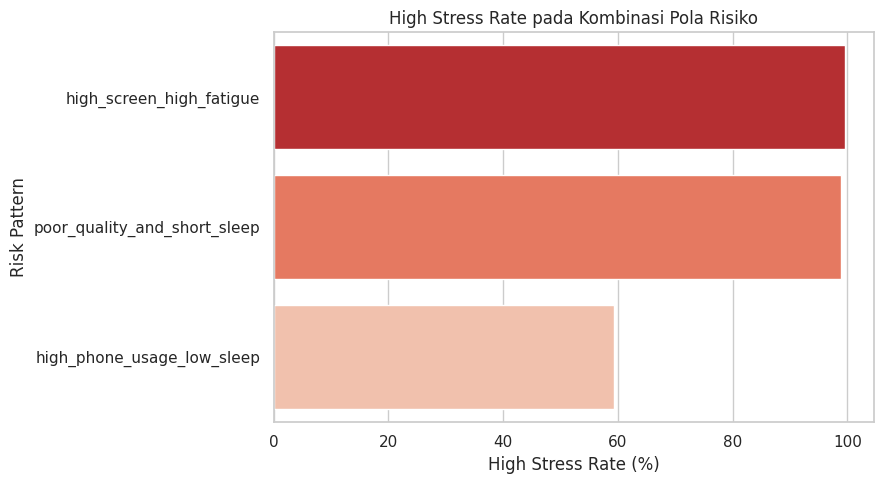

In [258]:
# ============================================================
# 9. EXPLANATORY ANALYSIS : Q4 - Kombinasi pola perilaku yang berisiko tinggi
# ============================================================

risk_features = [
    'poor_quality_and_short_sleep',
    'high_phone_usage_low_sleep',
    'high_screen_high_fatigue'
]

risk_features = [col for col in risk_features if col in df3_clean.columns]

risk_summary_list = []

for col in risk_features:
    temp = (
        df3_clean
        .groupby(col)
        .agg(
            users=('stress_level', 'count'),
            avg_stress_level=('stress_level', 'mean'),
            high_stress_rate=(target_col, lambda x: (x.astype(str).str.lower() == 'high').mean() * 100)
        )
        .round(2)
        .reset_index()
    )

    temp = temp.rename(columns={col: 'condition_value'})
    temp['risk_pattern'] = col
    risk_summary_list.append(temp)

risk_summary = pd.concat(risk_summary_list, ignore_index=True)
risk_summary = risk_summary[
    ['risk_pattern', 'condition_value', 'users', 'avg_stress_level', 'high_stress_rate']
]
display(risk_summary)

# Ambil hanya kondisi aktif / bernilai 1
risk_active = risk_summary[risk_summary[risk_summary.columns[0]] == 1].copy()

# Supaya lebih aman, buat ulang ringkasan aktif manual
active_rows = []

for col in risk_features:
    active_data = df3_clean[df3_clean[col] == 1]

    active_rows.append({
        'risk_pattern': col,
        'users': len(active_data),
        'avg_stress_level': active_data['stress_level'].mean(),
        'high_stress_rate': (active_data[target_col].astype(str).str.lower() == 'high').mean() * 100
    })

risk_active_summary = pd.DataFrame(active_rows).round(2)
risk_active_summary = risk_active_summary.sort_values('high_stress_rate', ascending=False)

display(risk_active_summary)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=risk_active_summary,
    x='high_stress_rate',
    y='risk_pattern',
    palette='Reds_r'
)

plt.title('High Stress Rate pada Kombinasi Pola Risiko')
plt.xlabel('High Stress Rate (%)')
plt.ylabel('Risk Pattern')
plt.tight_layout()
plt.show()


**Insight:**
- high_screen_high_fatigue memiliki **high stress rate tertinggi**, yaitu **99,65%,** dengan rata-rata stress level **9,71**. Ini artinya hampir semua pengguna dalam pola ini masuk kategori high stress.
- poor_quality_and_short_sleep juga sangat berisiko, dengan **high stress rate 98,88%** dan rata-rata stress level **9,75**. Ini artinya hampir semua pengguna dalam pola ini masuk kategori high stress.
- high_phone_usage_low_sleep memiliki high stress rate lebih rendah, yaitu **59,35%**, tetapi tetap lebih tinggi dibanding kondisi non-aktifnya.
- Visualisasi bar chart diatas menunjukkan bahwa dua pola kombinasi paling kuat adalah **high_screen_high_fatigue dan poor_quality_and_short_sleep**.
- Pola high_phone_usage_low_sleep tetap relevan, tetapi efeknya tidak sekuat kombinasi screen time/fatigue dan kualitas tidur buruk/tidur pendek.

**Jawaban Pertanyaan Bisnis:**
  - Kombinasi pola perilaku yang paling berisiko terhadap high stress adalah:
    - high_screen_high_fatigue
    - poor_quality_and_short_sleep
    - high_phone_usage_low_sleep

  Dari hasil ini, kombinasi screen time tinggi + mental fatigue tinggi menjadi pola risiko paling kuat.

  **Recommendation Action:**
  - Prioritaskan pengguna yang masuk pola high_screen_high_fatigue untuk intervensi paling awal atau pemberian rekomendasi khusus lebih personal, seperti memberikan rekomendasi screen time break (jeda layar berkala atau reminder istirahat).
  - Untuk pola poor_quality_and_short_sleep, berikan rekomendasi sleep hygiene, seperti menjaga jadwal tidur dan mengurangi aktivitas digital sebelum tidur.
  - Untuk pola high_phone_usage_low_sleep, berikan reminder untuk mengurangi penggunaan HP sebelum tidur.
  - Gunakan pola risiko ini sebagai dasar priority segment pada aplikasi.

,priority_segment,users,avg_stress_level,high_stress_rate,avg_screen_time,avg_sleep_quality
0,high_screen_low_sleep_quality,2889,9.94,100.00,8.72,3.92
1,high_screen_time,2078,9.23,96.92,8.24,5.90
2,low_sleep_quality,845,9.12,95.62,5.74,4.40
3,general_users,9188,5.34,25.89,3.85,7.23


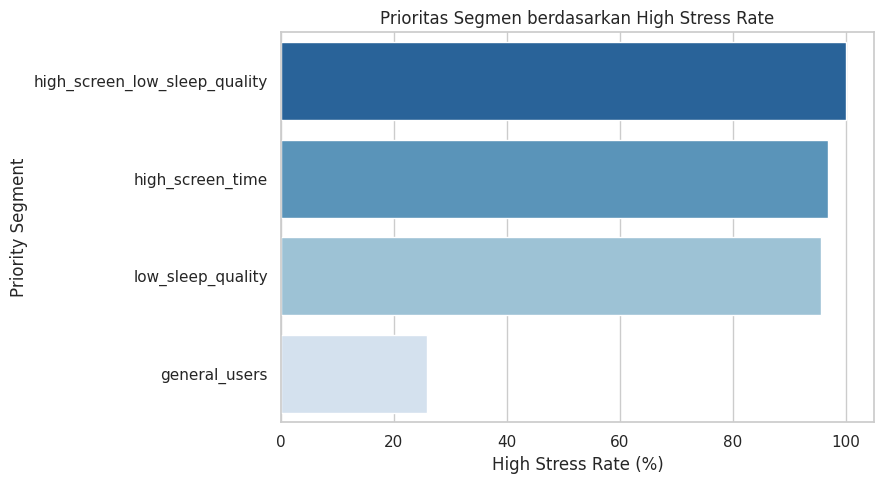

In [259]:
# ============================================================
# 9. EXPLANATORY ANALYSIS : Q5 - Segmentasi pengguna prioritas intervensi
# ============================================================

# Buat kategori tambahan jika belum tersedia
if 'daily_screen_time_category' not in df3_clean.columns:
    df3_clean['daily_screen_time_category'] = pd.cut(
        df3_clean['daily_screen_time_hours'],
        bins=[0, 3, 6, 24],
        labels=['low', 'medium', 'high'],
        include_lowest=True
    )

if 'sleep_quality_category' not in df3_clean.columns:
    df3_clean['sleep_quality_category'] = pd.cut(
        df3_clean['sleep_quality_score'],
        bins=[0, 4, 7, 10],
        labels=['poor', 'moderate', 'good'],
        include_lowest=True
    )

# Segmentasi sederhana berbasis temuan EDA
def assign_priority_segment(row):
    if (
        row['daily_screen_time_category'] == 'high'
        and row['sleep_quality_category'] == 'poor'
    ):
        return 'high_screen_low_sleep_quality'

    elif (
        row['daily_screen_time_category'] == 'high'
        and row['sleep_quality_category'] != 'poor'
    ):
        return 'high_screen_time'

    elif (
        row['sleep_quality_category'] == 'poor'
    ):
        return 'low_sleep_quality'

    else:
        return 'general_users'

df3_clean['priority_segment'] = df3_clean.apply(assign_priority_segment, axis=1)

segment_summary = (
    df3_clean
    .groupby('priority_segment')
    .agg(
        users=('stress_level', 'count'),
        avg_stress_level=('stress_level', 'mean'),
        high_stress_rate=(target_col, lambda x: (x.astype(str).str.lower() == 'high').mean() * 100),
        avg_screen_time=('daily_screen_time_hours', 'mean'),
        avg_sleep_quality=('sleep_quality_score', 'mean')
    )
    .round(2)
    .sort_values('high_stress_rate', ascending=False)
    .reset_index()
)

display(segment_summary)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=segment_summary,
    x='high_stress_rate',
    y='priority_segment',
    palette='Blues_r'
)

plt.title('Prioritas Segmen berdasarkan High Stress Rate')
plt.xlabel('High Stress Rate (%)')
plt.ylabel('Priority Segment')
plt.tight_layout()
plt.show()

**Insight:**
- Segmen high_screen_low_sleep_quality adalah segmen paling kritis:
  - jumlah pengguna: 2.889
  - rata-rata stress level: 9,94
  - high stress rate: 100%
  - rata-rata screen time: 8,72 jam
  - rata-rata sleep quality: 3,92
- Segmen high_screen_time juga sangat berisiko:
  - high stress rate: 96,92%
  - rata-rata stress level: 9,23
  - screen time tinggi, yaitu 8,24 jam
- Segmen low_sleep_quality juga perlu diperhatikan:
  - high stress rate: 95,62%
  - rata-rata stress level: 9,12
- Segmen general_users jauh lebih rendah risikonya:
  - high stress rate hanya 25,89%
  - rata-rata stress level 5,34

**Jawaban Pertanyaan Bisnis:**
- Segmen yang perlu diprioritaskan adalah pengguna dengan kombinasi high screen time + low sleep quality, karena segmen ini memiliki high stress rate tertinggi sebesar 100%.
- **Urutan prioritas intervensi:**
  1. high_screen_low_sleep_quality
  2. high_screen_time
  3. low_sleep_quality
  4. general_users

**Rekomendasi Bisnis:**
- Untuk segmen high_screen_low_sleep_quality, dapat berikan intervensi rekomendasi aktivitas paling kuat:
  - reminder mengurangi screen time,
  - rekomendasi sleep hygiene,
  - evaluasi stres harian,
  - notifikasi untuk istirahat dari layar.

- Untuk segmen high_screen_time, fokus pada:
  - fitur pembatasan screen time limit pada gagdet user,
  - fitur pengingat break reminder,
  - rekomendasi aktivitas non-digital.

- Untuk segmen low_sleep_quality, fokus pada:
  - tips kualitas tidur,
  - reminder jadwal tidur,
  - edukasi kebiasaan sebelum tidur.
- Untuk general_users, cukup berikan monitoring ringan dan rekomendasi preventif.

## 10. Penyesuaian Hasil EDA dengan Fitur Model Deployment

- Berdasarkan hasil EDA, fitur yang paling kuat berkaitan dengan kategori stres adalah mental_fatigue_score, daily_screen_time_hours, dan sleep_quality_score. Namun, pada input user aplikasi tidak memungkinkan beberapa fitur tersebut menjadi fitur input user, sehingga fitur seperti mental_fatigue_score tidak dimasukkan kedalam dataset bersih untuk pembangunan model yang akan dikembangkan dan di-deploy, sehingga fitur yang dipilih untuk dataset model yaitu fitur yang juga cocok untuk menjadi fitur input user yang lebih sederhana dan lebih mudah dikumpulkan dari pengguna aplikasi ataupun fitur turunan dari fitur tersebut.

- Oleh karena itu, dataset final untuk modeling disesuaikan dengan fitur input user yang akan digunakan pada model AI/deployment, yaitu age, gender, sleep_hours, sleep_quality_score, daily_screen_time_hours, dan phone_usage_before_sleep_minutes. Fitur mental_fatigue_score tetap dicatat sebagai fitur penting dan direkomendasikan untuk pengembangan model berikutnya.

In [260]:
# ============================================================
# 10. Penyesuaian Hasil EDA dengan Fitur Model Deployment: FINAL MODEL-READY DATASET - Fitur yang dipilih disesuaikan dengan fitur yang memungkiinkan untuk menjadi input user
# ============================================================

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Target yang digunakan model
target_col = 'stress_category'

# Menyesuaikan nama kolom tidur
sleep_col = 'sleep_hours' if 'sleep_hours' in df3_clean.columns else 'sleep_duration_hours'

# Fitur df3 yang digunakan pada pipeline role AI
df3_ai_features = [
    'age',
    sleep_col,
    'sleep_quality_score',
    'sleep_quality_category',
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'phone_usage_before_sleep_category',
    'poor_quality_and_short_sleep',
    'high_phone_usage_low_sleep',
    'occupation',
    'gender'
]

# Ambil hanya fitur yang benar-benar ada di df3_clean
df3_ai_features = [col for col in df3_ai_features if col in df3_clean.columns]

# Ambil data yang dibutuhkan saja
df3_model_raw = df3_clean[df3_ai_features + [target_col]].copy()

# Samakan nama sleep menjadi sleep_hours agar konsisten dengan role AI
if sleep_col != 'sleep_hours':
    df3_model_raw = df3_model_raw.rename(columns={sleep_col: 'sleep_hours'})
    df3_ai_features = [
        'sleep_hours' if col == sleep_col else col
        for col in df3_ai_features
    ]

# Hapus baris yang targetnya kosong
df3_model_raw = df3_model_raw.dropna(subset=[target_col]).reset_index(drop=True)

# Pisahkan fitur dan target
X_df3 = df3_model_raw[df3_ai_features].copy()
y_df3 = df3_model_raw[target_col].copy()

# Pisahkan kolom numerik dan kategorikal
numeric_cols = [
    col for col in df3_ai_features
    if pd.api.types.is_numeric_dtype(X_df3[col])
]

categorical_cols = [
    col for col in df3_ai_features
    if not pd.api.types.is_numeric_dtype(X_df3[col])
]

print("Fitur numerik yang akan di-scaling:")
print(numeric_cols)

print("\nFitur kategorikal yang akan di-encoding:")
print(categorical_cols)

print("\nDistribusi target:")
display(
    y_df3.value_counts()
    .reset_index()
    .rename(columns={'index': target_col, target_col: 'count'})
)

# OneHotEncoder dibuat fleksibel agar tetap jalan di beberapa versi sklearn
try:
    onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

# Pipeline numerik dan kategorikal
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot_encoder)
])

# Gabungkan preprocessing
df3_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

# Fit dan transform data
X_df3_processed = df3_preprocessor.fit_transform(X_df3)

# Ambil nama fitur setelah encoding + scaling langsung dari preprocessor
processed_feature_names = df3_preprocessor.get_feature_names_out()

# Rapikan nama fitur agar tidak ada prefix num__ dan cat__
processed_feature_names = [
    name.replace('num__', '').replace('cat__', '')
    for name in processed_feature_names
]

print("Jumlah nama fitur:", len(processed_feature_names))
print("Jumlah kolom X processed:", X_df3_processed.shape[1])

# Ubah hasil preprocessing menjadi dataframe
X_df3_processed = pd.DataFrame(
    X_df3_processed,
    columns=processed_feature_names,
    index=df3_model_raw.index
)

# Encode target
label_encoder_df3 = LabelEncoder()
y_df3_encoded = label_encoder_df3.fit_transform(y_df3)

# Dataset final siap model
df3_model_ready_ai = X_df3_processed.copy()
df3_model_ready_ai[target_col] = y_df3.values
df3_model_ready_ai[target_col + '_encoded'] = y_df3_encoded

print("\nShape sebelum preprocessing:")
print("X:", X_df3.shape)

print("\nShape setelah encoding + scaling:")
print("X processed:", X_df3_processed.shape)

print("\nTarget encoding:")
for label, code in zip(label_encoder_df3.classes_, label_encoder_df3.transform(label_encoder_df3.classes_)):
    print(f"{label} -> {code}")

print("\nContoh data siap model:")
display(df3_model_ready_ai.head())

Fitur numerik yang akan di-scaling:
['age', 'sleep_hours', 'sleep_quality_score', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'poor_quality_and_short_sleep', 'high_phone_usage_low_sleep']

Fitur kategorikal yang akan di-encoding:
['sleep_quality_category', 'phone_usage_before_sleep_category', 'occupation', 'gender']

Distribusi target:


,count,count
0,high,8090
1,medium,4190
2,low,2720


Jumlah nama fitur: 24
Jumlah kolom X processed: 24

Shape sebelum preprocessing:
X: (15000, 11)

Shape setelah encoding + scaling:
X processed: (15000, 24)

Target encoding:
high -> 0
low -> 1
medium -> 2

Contoh data siap model:


,age,sleep_hours,sleep_quality_score,daily_screen_time_hours,phone_usage_before_sleep_minutes,poor_quality_and_short_sleep,high_phone_usage_low_sleep,sleep_quality_category_good,sleep_quality_category_moderate,sleep_quality_category_poor,...,occupation_Manager,occupation_Researcher,occupation_Software Engineer,occupation_Student,occupation_Teacher,gender_Female,gender_Male,gender_Other,stress_category,stress_category_encoded
0,1.458374,-0.825864,0.859973,-0.862127,0.758965,-0.335428,2.006691,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,low,1
1,0.625566,0.585359,2.015443,-1.404435,-0.799895,-0.335428,-0.498333,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,low,1
2,-0.540365,-1.383469,0.077987,-0.946742,1.365188,-0.335428,2.006691,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,medium,2
3,-1.123330,0.117246,-0.418048,1.345567,-0.684424,-0.335428,-0.498333,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,high,0
4,-0.040680,0.729924,0.258894,-0.762127,-0.107069,-0.335428,-0.498333,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,medium,2


Shape data:
X_train: (12000, 24)
X_test : (3000, 24)
y_train: (12000,)
y_test : (3000,)

Baseline Random Forest Performance - Dataset 3
Accuracy : 0.8477
F1 Macro : 0.8140

Classification Report:
              precision    recall  f1-score   support

        high       0.93      0.93      0.93      1618
         low       0.80      0.76      0.78       544
      medium       0.72      0.74      0.73       838

    accuracy                           0.85      3000
   macro avg       0.82      0.81      0.81      3000
weighted avg       0.85      0.85      0.85      3000



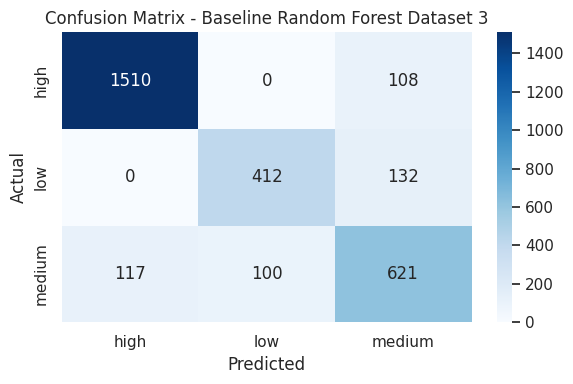


Top 15 Feature Importance:


,feature,importance
3,daily_screen_time_hours,0.304283
2,sleep_quality_score,0.255350
7,sleep_quality_category_good,0.076293
1,sleep_hours,0.065620
4,phone_usage_before_sleep_minutes,0.061655
0,age,0.057599
9,sleep_quality_category_poor,0.046308
8,sleep_quality_category_moderate,0.045417
5,poor_quality_and_short_sleep,0.009997
22,gender_Male,0.006910


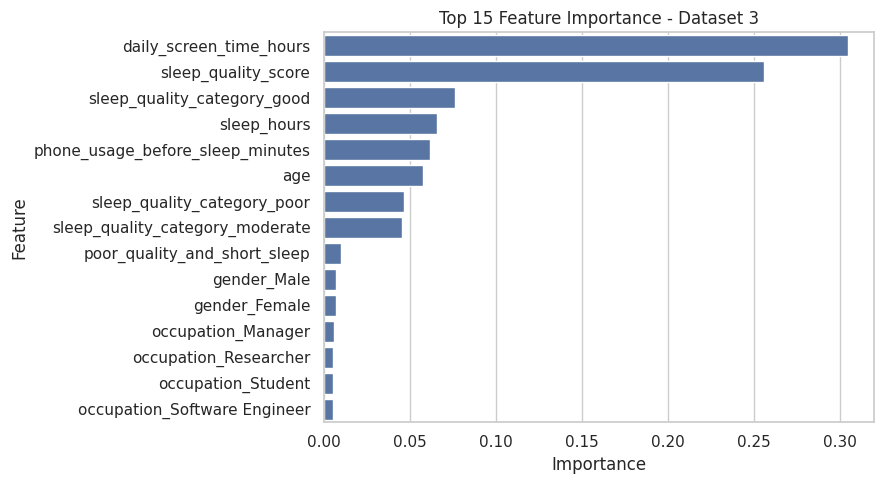

In [261]:
# ============================================================
# 10. Penyesuaian Hasil EDA dengan Fitur Model Deployment: BASELINE MODEL DAN FEATURE IMPORTANCE - Fitur yang dipilih disesuaikan dengan fitur yang memungkiinkan untuk menjadi input user
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Supaya hasil split dan model tetap konsisten saat notebook dijalankan ulang
RANDOM_STATE = 42

# Fitur yang sudah melalui encoding + scaling
X_model = X_df3_processed.copy()

# Target yang sudah diubah menjadi angka
y_model = y_df3_encoded.copy()

# Split data train dan test
X_train_ready, X_test_ready, y_train_encoded, y_test_encoded = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_model
)

print("Shape data:")
print("X_train:", X_train_ready.shape)
print("X_test :", X_test_ready.shape)
print("y_train:", y_train_encoded.shape)
print("y_test :", y_test_encoded.shape)

# Model baseline
baseline_model_df3 = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1
)

baseline_model_df3.fit(X_train_ready, y_train_encoded)

# Prediksi data test
y_pred = baseline_model_df3.predict(X_test_ready)

# Evaluasi model
accuracy = accuracy_score(y_test_encoded, y_pred)
f1_macro = f1_score(y_test_encoded, y_pred, average='macro')

print("\nBaseline Random Forest Performance - Dataset 3")
print(f"Accuracy : {accuracy:.4f}")
print(f"F1 Macro : {f1_macro:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder_df3.classes_
    )
)

# Confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder_df3.classes_,
    yticklabels=label_encoder_df3.classes_
)

plt.title('Confusion Matrix - Baseline Random Forest Dataset 3')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance dari Random Forest
feature_importance_df3 = pd.DataFrame({
    'feature': processed_feature_names,
    'importance': baseline_model_df3.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Feature Importance:")
display(feature_importance_df3.head(15))

plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_importance_df3.head(15),
    x='importance',
    y='feature'
)

plt.title('Top 15 Feature Importance - Dataset 3')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [262]:
# ============================================================
# 10. Penyesuaian Hasil EDA dengan Fitur Model Deployment : Data Dictionary dan EXPORT DATASET FINAL MODEL_READY - Fitur yang dipilih disesuaikan dengan fitur yang memungkiinkan untuk menjadi input user
# ============================================================

output_dir = 'df3_project_outputs'
os.makedirs(output_dir, exist_ok=True)

# Data lengkap hasil cleaning + feature engineering
df3_clean.to_csv(f'{output_dir}/df3_clean.csv', index=False)

# Data raw yang fiturnya sudah sesuai role AI, tetapi belum encoding/scaling
df3_model_raw.to_csv(
    f'{output_dir}/df3_model_ready_raw.csv',
    index=False
)

# Data siap model: sudah encoding + scaling
df3_model_ready_ai.to_csv(
    f'{output_dir}/df3_model_ready_.csv',
    index=False
)

# Data dictionary tetap boleh disimpan
data_dictionary_df3.to_csv(
    f'{output_dir}/data_dictionary_df3_model_ready.csv',
    index=False
)

print('File berhasil dibuat:')
print('- df3_project_outputs/df3_clean.csv')
print('- df3_project_outputs/df3_model_ready_raw.csv')
print('- df3_project_outputs/df3_model_ready.csv')
print('- df3_project_outputs/data_dictionary_df3_model_ready.csv')

File berhasil dibuat:
- df3_project_outputs/df3_clean.csv
- df3_project_outputs/df3_model_ready_raw.csv
- df3_project_outputs/df3_model_ready.csv
- df3_project_outputs/data_dictionary_df3_model_ready.csv


---
## 11. Dataset Pengembangan Lanjutan — Rekomendasi Fitur dari Hasil EDA

Menyiapkan alternatif dataset model untuk pengembangan berikutnya berdasarkan hasil EDA. Berbeda dengan dataset yang digunakan pada model deployment saat ini, dataset ini memasukkan fitur yang terbukti lebih informatif terhadap kategori stres, seperti mental_fatigue_score, daily_screen_time_hours, sleep_quality_score, dan fitur hasil feature engineering tertentu.

Dataset ini tidak digunakan sebagai input utama pada deployment saat ini karena beberapa fitur, seperti mental_fatigue_score, belum tersedia sebagai input user pada aplikasi. Namun, dataset ini dapat menjadi rekomendasi untuk iterasi model selanjutnya apabila aplikasi menambahkan input tambahan atau kuesioner singkat terkait kelelahan mental.

In [263]:
# ============================================================
# 11. Dataset Pengembangan Lanjutan : PREPROCESSING DATA SIAP MODEL
# ============================================================

# Fitur yang dipakai untuk model Dataset 3
feature_cols = [
    'age',
    'gender',
    'occupation',
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'sleep_hours',
    'sleep_quality_score',
    'caffeine_intake_cups',
    'physical_activity_minutes',
    'notifications_received_per_day',
    'mental_fatigue_score',
    'sleep_duration_category',
    'sleep_quality_category',
    'phone_usage_before_sleep_category',
    'daily_screen_time_category',
    'sleep_deficit_hours',
    'poor_quality_and_short_sleep',
    'high_phone_usage_low_sleep',
    'high_screen_high_fatigue',
    'notification_intensity_per_hour'
]

target_col = 'stress_category'

X = df3_clean[feature_cols].copy()
y = df3_clean[target_col].copy()

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print('Jumlah fitur numerik:', len(numeric_cols))
print(numeric_cols)
print('\nJumlah fitur kategorikal:', len(categorical_cols))
print(categorical_cols)

# Split data secara stratified agar distribusi target di train-test tetap mirip
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ],
    remainder='drop'
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Ambil nama fitur setelah encoding
encoded_cat_cols = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
processed_feature_names = numeric_cols + encoded_cat_cols.tolist()

X_train_ready = pd.DataFrame(X_train_processed, columns=processed_feature_names, index=X_train.index)
X_test_ready = pd.DataFrame(X_test_processed, columns=processed_feature_names, index=X_test.index)

# Encode target
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

df3_model_ready = pd.concat([
    pd.DataFrame(preprocessor.transform(X), columns=processed_feature_names, index=X.index),
    pd.Series(label_encoder.transform(y), name='target_encoded', index=X.index),
    y.reset_index(drop=True).rename('stress_category')
], axis=1)

print('Shape X_train sebelum preprocessing :', X_train.shape)
print('Shape X_train sesudah preprocessing:', X_train_ready.shape)
print('Shape X_test sesudah preprocessing :', X_test_ready.shape)
print('\nMapping target:')
for label, code in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f'- {label} -> {code}')

display(df3_model_ready.head())

Jumlah fitur numerik: 14
['age', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_hours', 'sleep_quality_score', 'caffeine_intake_cups', 'physical_activity_minutes', 'notifications_received_per_day', 'mental_fatigue_score', 'sleep_deficit_hours', 'poor_quality_and_short_sleep', 'high_phone_usage_low_sleep', 'high_screen_high_fatigue', 'notification_intensity_per_hour']

Jumlah fitur kategorikal: 6
['gender', 'occupation', 'sleep_duration_category', 'sleep_quality_category', 'phone_usage_before_sleep_category', 'daily_screen_time_category']
Shape X_train sebelum preprocessing : (12000, 20)
Shape X_train sesudah preprocessing: (12000, 37)
Shape X_test sesudah preprocessing : (3000, 37)

Mapping target:
- high -> 0
- low -> 1
- medium -> 2


,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_hours,sleep_quality_score,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,sleep_deficit_hours,...,sleep_quality_category_moderate,sleep_quality_category_poor,phone_usage_before_sleep_category_high,phone_usage_before_sleep_category_low,phone_usage_before_sleep_category_medium,daily_screen_time_category_high,daily_screen_time_category_low,daily_screen_time_category_moderate,target_encoded,stress_category
0,1.453605,-0.856995,0.765360,-0.831780,0.860588,-1.415721,-0.694738,-0.519083,-1.207038,0.801763,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1,low
1,0.620892,-1.398381,-0.794305,0.582270,2.017844,-1.415721,-1.244087,1.704756,-1.814529,-0.901027,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1,low
2,-0.544907,-0.941466,1.371896,-1.390502,0.077394,-1.415721,-1.215174,-1.729840,-0.299460,1.617894,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2,medium
3,-1.127806,1.346946,-0.678774,0.113219,-0.419408,-1.415721,-1.619957,0.728738,1.116801,-0.578605,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0,high
4,-0.045279,-0.757165,-0.101121,0.727124,0.258581,1.409952,0.953308,0.073941,-0.321417,-0.901027,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2,medium


Baseline Random Forest Performance
Accuracy : 0.8940
F1 Macro : 0.8695

Classification Report:
              precision    recall  f1-score   support

        high       0.95      0.96      0.95      1618
         low       0.86      0.83      0.84       544
      medium       0.81      0.82      0.81       838

    accuracy                           0.89      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.89      0.89      0.89      3000



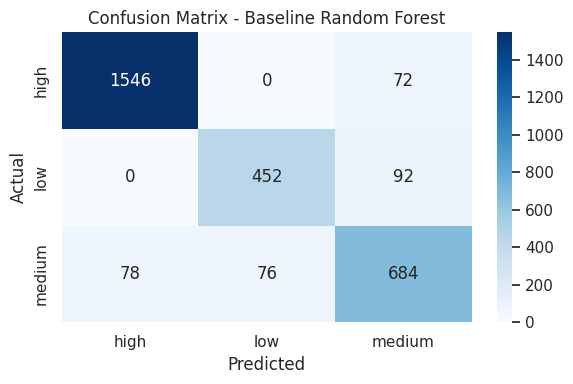

,feature,importance
8,mental_fatigue_score,0.266008
1,daily_screen_time_hours,0.157718
4,sleep_quality_score,0.127951
28,sleep_quality_category_good,0.057421
35,daily_screen_time_category_low,0.052494
34,daily_screen_time_category_high,0.034399
29,sleep_quality_category_moderate,0.027956
12,high_screen_high_fatigue,0.025926
2,phone_usage_before_sleep_minutes,0.023461
36,daily_screen_time_category_moderate,0.023271


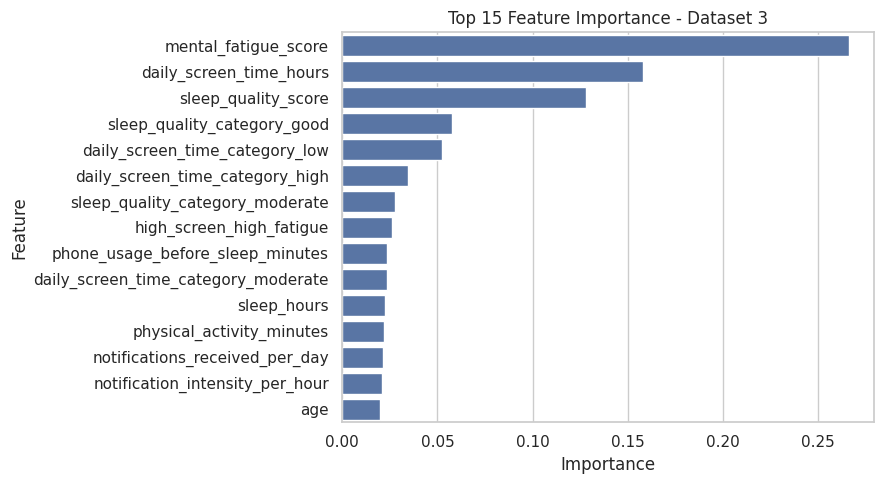

In [264]:
# ============================================================
# 11. Dataset Pengembangan Lanjutan : BASELINE MODEL DAN FEATURE IMPORTANCE
# ============================================================

baseline_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

baseline_model.fit(X_train_ready, y_train_encoded)
y_pred = baseline_model.predict(X_test_ready)

accuracy = accuracy_score(y_test_encoded, y_pred)
f1_macro = f1_score(y_test_encoded, y_pred, average='macro')

print('Baseline Random Forest Performance')
print(f'Accuracy : {accuracy:.4f}')
print(f'F1 Macro : {f1_macro:.4f}')
print('\nClassification Report:')
print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Baseline Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

feature_importance_df3 = pd.DataFrame({
    'feature': processed_feature_names,
    'importance': baseline_model.feature_importances_
}).sort_values('importance', ascending=False)

display(feature_importance_df3.head(15))

plt.figure(figsize=(9, 5))
sns.barplot(data=feature_importance_df3.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importance - Dataset 3')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

---
## 11. Dataset Pengembangan Lanjutan : Data Dictionary dan Export File — Memastikan Data Siap Diproses oleh Model

Menyimpan data bersih, data siap model, ringkasan insight, dan data dictionary.

In [265]:
# ============================================================
# 11. Dataset Pengembangan Lanjutan : DATA DICTIONARY + EXPORT FILE
# ============================================================

feature_descriptions = {
    'user_id': 'ID unik pengguna. Tidak digunakan sebagai fitur model.',
    'age': 'Usia pengguna.',
    'gender': 'Jenis kelamin pengguna.',
    'occupation': 'Pekerjaan pengguna.',
    'daily_screen_time_hours': 'Total durasi screen time harian dalam jam.',
    'phone_usage_before_sleep_minutes': 'Durasi penggunaan ponsel sebelum tidur dalam menit.',
    'sleep_hours': 'Durasi tidur dalam jam.',
    'sleep_quality_score': 'Skor kualitas tidur pengguna.',
    'stress_level': 'Skor tingkat stres numerik 1-10.',
    'caffeine_intake_cups': 'Jumlah konsumsi kafein per hari dalam cangkir.',
    'physical_activity_minutes': 'Durasi aktivitas fisik harian dalam menit.',
    'notifications_received_per_day': 'Jumlah notifikasi yang diterima per hari.',
    'mental_fatigue_score': 'Skor kelelahan mental.',
    'stress_category': 'Kategori target stres: low, medium, high.',
    'sleep_duration_category': 'Kategori durasi tidur: short, ideal, long.',
    'sleep_quality_category': 'Kategori kualitas tidur: low, medium, high.',
    'phone_usage_before_sleep_category': 'Kategori penggunaan HP sebelum tidur.',
    'daily_screen_time_category': 'Kategori screen time harian.',
    'sleep_deficit_hours': 'Selisih kekurangan tidur dari 7 jam, minimum 0.',
    'poor_quality_and_short_sleep': 'Flag 1 jika kualitas tidur rendah dan tidur kurang dari 6 jam.',
    'high_phone_usage_low_sleep': 'Flag 1 jika penggunaan HP sebelum tidur tinggi dan tidur kurang dari 6 jam.',
    'high_screen_high_fatigue': 'Flag 1 jika screen time tinggi dan mental fatigue tinggi.',
    'notification_intensity_per_hour': 'Rata-rata notifikasi per jam.'
}

data_dictionary_df3 = pd.DataFrame({
    'column': df3_clean.columns,
    'dtype': [str(df3_clean[col].dtype) for col in df3_clean.columns],
    'missing_count': [df3_clean[col].isna().sum() for col in df3_clean.columns],
    'unique_count': [df3_clean[col].nunique() for col in df3_clean.columns],
    'description': [feature_descriptions.get(col, 'Kolom turunan atau fitur tambahan untuk analisis/modeling.') for col in df3_clean.columns]
})

display(data_dictionary_df3)

# Export file utama
output_dir = 'df3_project_outputs'
os.makedirs(output_dir, exist_ok=True)

df3_clean.to_csv(f'{output_dir}/df3_clean.csv', index=False)
df3_model_ready.to_csv(f'{output_dir}/df3_future_model_ready.csv', index=False)
data_dictionary_df3.to_csv(f'{output_dir}/data_dictionary_df3_future_model.csv', index=False)
feature_importance_df3.to_csv(f'{output_dir}/feature_importance__df3_future_model.csv', index=False)
target_summary.to_csv(f'{output_dir}/target_distribution__df3_future_model.csv', index=False)
segment_summary.to_csv(f'{output_dir}/segment_priority__df3_future_model.csv', index=False)

print('File berhasil dibuat')
print('- df3_project_outputs/df3_clean.csv')
print('- df3_project_outputs/df3_future_model_ready.csv')
print('- df3_project_outputs/data_dictionary_df3_future_model.csv')
print('- df3_project_outputs/feature_importance_df3_future_model.csv')
print('- df3_project_outputs/target_distribution_df3_future_model.csv')
print('- df3_project_outputs/segment_priority_df3_future_model.csv')

,column,dtype,missing_count,unique_count,description
0,age,int64,0,42,Usia pengguna.
1,gender,object,0,3,Jenis kelamin pengguna.
2,occupation,object,0,8,Pekerjaan pengguna.
3,daily_screen_time_hours,float64,0,901,Total durasi screen time harian dalam jam.
4,phone_usage_before_sleep_minutes,int64,0,120,Durasi penggunaan ponsel sebelum tidur dalam m...
5,sleep_hours,float64,0,501,Durasi tidur dalam jam.
6,sleep_quality_score,float64,0,831,Skor kualitas tidur pengguna.
7,stress_level,float64,0,900,Skor tingkat stres numerik 1-10.
8,caffeine_intake_cups,int64,0,5,Jumlah konsumsi kafein per hari dalam cangkir.
9,physical_activity_minutes,int64,0,120,Durasi aktivitas fisik harian dalam menit.


File berhasil dibuat
- df3_project_outputs/df3_clean.csv
- df3_project_outputs/df3_future_model_ready.csv
- df3_project_outputs/data_dictionary_df3_future_model.csv
- df3_project_outputs/feature_importance_df3_future_model.csv
- df3_project_outputs/target_distribution_df3_future_model.csv
- df3_project_outputs/segment_priority_df3_future_model.csv
